# Découverte de Pattern Functional Dependencies

**M2 MIAGE APP - Data Quality — Université Paris Dauphine**

**Abdrahamane CAMARA - Yuxuan CHEN - Gide FORMAT - Hongxiang LIN - Liya XU**

Le notebook regroupe le code et les expériences pour les trois tâches du mini-projet.

Pour la tâche 1, on a écrit un algorithme classique de découverte de PFDs en quatre étapes : extraction des motifs candidats sur chaque colonne, génération des PFDs candidates, validation par calcul de confiance, puis généralisation des règles redondantes.

Pour la tâche 2, on a implémenté deux workflows agentiques qui s'appuient sur des LLMs. Le Workflow B (Guided Search) demande au LLM de proposer directement des candidats, qu'on valide ensuite avec le module de la tâche 1. Le Workflow C (Agent in the Loop) ajoute une boucle de raffinement : le LLM corrige ses propres erreurs en voyant les violations, puis on lui demande s'il a oublié quelque chose.

Pour la tâche 3, on compare ces approches sur les trois datasets fournis par le cours, avec trois LLMs différents : Gemini, Groq (Llama) et Mistral. Les trois disposent d'un tier gratuit permanent, ce qui permet de relancer l'expérience sans coût.

L'objectif est de comparer la couverture et la qualité des règles trouvées par chaque approche, et de voir si les workflows agentiques peuvent rivaliser avec l'algorithme classique tout en testant beaucoup moins de candidats.

## 0. Installation et imports

In [10]:
!pip install google-genai groq mistralai pandas matplotlib python-dotenv -q
print("Librairies installées.")

Librairies installées.


In [11]:
import os
import re
import csv
import json
import time
from collections import defaultdict, Counter
from itertools import groupby

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print("Imports OK.")

Imports OK.


## 1. Chargement des clés API


In [12]:
try:
    from google.colab import userdata
    GEMINI_KEY   = userdata.get('GEMINI_API_KEY')
    GROQ_KEY     = userdata.get('GROQ_API_KEY')
    MISTRAL_KEY  = userdata.get('MISTRAL_API_KEY')
    print("Clés chargées depuis Google Colab.")
except (ImportError, ModuleNotFoundError):
    from dotenv import load_dotenv
    load_dotenv()
    GEMINI_KEY   = os.getenv('GEMINI_API_KEY')
    GROQ_KEY     = os.getenv('GROQ_API_KEY')
    MISTRAL_KEY  = os.getenv('MISTRAL_API_KEY')
    print("Clés chargées depuis .env.")

# On affiche un statut pour chaque LLM. Si une clé manque, le LLM correspondant
# sera désactivé dans les expériences, mais le notebook continuera de tourner.
def _statut(name, key):
    if key:
        print(f"  {name:<10} : OK ({key[:8]}...)")
        return True
    else:
        print(f"  {name:<10} : MANQUANT (sera ignoré)")
        return False

available_llms = {
    'gemini':  _statut('Gemini',  GEMINI_KEY),
    'groq':    _statut('Groq',    GROQ_KEY),
    'mistral': _statut('Mistral', MISTRAL_KEY),
}

if not any(available_llms.values()):
    raise RuntimeError("Aucune clé API disponible. Le notebook ne peut pas continuer.")

Clés chargées depuis Google Colab.
  Gemini     : OK (AIzaSyA7...)
  Groq       : OK (gsk_0aHA...)
  Mistral    : OK (AYMNEJCH...)


## 2. Rappels théoriques

### Dépendance fonctionnelle classique

On note `X → Y` la dépendance fonctionnelle qui exprime que la valeur de `Y` est déterminée par celle de `X`. Formellement, pour tous tuples `t` et `t'` d'une relation, on a :

> *t[X] = t'[X]  ⇒  t[Y] = t'[Y]*

Autrement dit, deux lignes qui s'accordent sur X doivent s'accorder sur Y.

### Pattern Functional Dependency (PFD)

Une PFD généralise la FD en autorisant des **motifs** plutôt que l'égalité stricte :

> *(X, λ_X) → (Y, λ_Y)*

où `λ_X` est un motif sur X (par exemple « commence par 606 ») et `λ_Y` un motif sur Y (par exemple « est égal à Chicago »).

> **Exemple canonique du cours** : sur t2, la PFD `(ZIP, startswith="606") → (CITY, exact="Chicago")` est satisfaite à 98,3 %.

### PFD approximative

Une PFD est dite approximative quand on accepte qu'elle soit violée par une petite fraction `ε` des tuples. Elle est considérée valide si :

- son **support** (nombre de lignes où X matche λ_X) atteint un seuil `min_support`,
- et sa **confiance** (`n_valid / n_matching_X`) atteint `1 − ε`.

Dans nos expériences nous utilisons `ε = 0.1`, ce qui correspond à une confiance minimale de 90 %.

## 3. Tâche 1 — Algorithme classique

Pour la tâche 1, on a découpé le pipeline en quatre modules indépendants. Cette organisation rend chaque étape testable isolément et facilite les évolutions futures.

| Module | Rôle |
|---|---|
| `pfd_verifier` | Vérifie qu'une PFD candidate satisfait le seuil de confiance |
| `pattern_extractor` | Extrait les motifs candidats de chaque colonne (préfixes, premiers tokens) |
| `candidate_generator` | Produit les paires (X, λ_X) → (Y, top_Y) à tester |
| `rule_generalizer` | Fusionne les règles spécifiques en règles générales et élague les dominées |

L'orchestration finale est faite par la fonction `discover` qui enchaîne les quatre étapes.

### 3.1 — Module `pfd_verifier`

Cette fonction calcule la confiance d'une PFD candidate, qui est définie comme le ratio entre le nombre de lignes où X et Y matchent tous les deux et le nombre de lignes où X seul matche. La règle est validée si cette confiance dépasse le seuil `1 − ε`.

In [13]:
def _match_pattern(series, pattern, match_type):
    """
    Applique un matching de pattern sur une Series pandas.

    Les valeurs NaN ne correspondent jamais à un pattern.

    Paramètres
    ----------
    series     : pd.Series   Colonne à tester.
    pattern    : any         Valeur ou expression à rechercher.
    match_type : str         Type de matching :
                               - 'exact'      : égalité stricte
                               - 'startswith' : la valeur commence par pattern
                               - 'endswith'   : la valeur finit par pattern
                               - 'contains'   : la valeur contient pattern
                               - 'regex'      : pattern est une regex

    Retourne
    --------
    pd.Series[bool]   Masque booléen de même index que series.
    """
    if match_type == "exact":
        # NaN == X est False nativement dans pandas, pas besoin de notna()
        return series == pattern

    # Pour startswith / endswith / contains / regex : conversion en str obligatoire.
    # NaN devient la chaîne "nan" après astype(str) — on l'exclut via notna().
    not_null    = series.notna()
    s           = series.astype(str)
    pattern_str = str(pattern)

    if match_type == "startswith":
        return not_null & s.str.startswith(pattern_str)

    elif match_type == "endswith":
        return not_null & s.str.endswith(pattern_str)

    elif match_type == "contains":
        return not_null & s.str.contains(pattern_str, regex=False, na=False)

    elif match_type == "regex":
        # Validation de la syntaxe avant application pour un message d'erreur clair
        try:
            re.compile(pattern_str)
        except re.error as e:
            raise ValueError(f"Pattern regex invalide '{pattern_str}' : {e}")
        return not_null & s.str.contains(pattern_str, regex=True, na=False)

    else:
        raise ValueError(
            f"match_type inconnu : '{match_type}'. "
            "Valeurs acceptées : 'exact', 'startswith', 'endswith', 'contains', 'regex'."
        )


# La liste des types de matching que nos LLMs peuvent proposer. On l'utilise
# pour filtrer les candidats avant validation et éviter des crashes si un LLM
# invente un type inconnu (par exemple Groq a tendance à proposer "endswith"
# alors qu'on ne lui demande pas explicitement).
VALID_MATCH_TYPES = {"exact", "startswith", "endswith", "contains", "regex"}


def verifier_pfd(df, col_X, pattern_X, col_Y, pattern_Y,
                 epsilon=0.05, match_type="exact",
                 match_type_X=None, match_type_Y=None):
    """
    Vérifie une PFD approximative sur un DataFrame pandas.

    Règle vérifiée : col_X correspond à pattern_X  ->  col_Y correspond à pattern_Y
    PFD valide si confiance >= (1 - epsilon).

    Retourne un dict avec confidence, is_valid, n_matching_X, n_valid,
    n_violations, epsilon et examples_violations (jusqu'à 3 lignes en violation).
    """
    mt_X = match_type_X if match_type_X is not None else match_type
    mt_Y = match_type_Y if match_type_Y is not None else match_type

    # Étape 1 — masque sur l'antécédent (col_X)
    mask_X       = _match_pattern(df[col_X], pattern_X, mt_X)
    n_matching_X = int(mask_X.sum())

    # Cas dégénéré : aucune ligne ne correspond à pattern_X
    if n_matching_X == 0:
        return {
            "confidence":          0.0,
            "is_valid":            False,
            "n_matching_X":        0,
            "n_valid":             0,
            "n_violations":        0,
            "epsilon":             epsilon,
            "examples_violations": [],
        }

    # Étape 2 — restreindre aux lignes où X matche
    df_X = df[mask_X].copy()

    # Étape 3 — masque sur le conséquent (col_Y) dans ce sous-ensemble
    mask_Y       = _match_pattern(df_X[col_Y], pattern_Y, mt_Y)
    n_valid      = int(mask_Y.sum())
    n_violations = n_matching_X - n_valid

    # Calcul de la confiance et décision
    confidence = n_valid / n_matching_X
    is_valid   = confidence >= (1.0 - epsilon)

    # Collecte des 3 premières violations pour analyse
    violations_df       = df_X[~mask_Y]
    examples_violations = violations_df.head(3).to_dict("records")

    return {
        "confidence":          round(confidence, 6),
        "is_valid":            is_valid,
        "n_matching_X":        n_matching_X,
        "n_valid":             n_valid,
        "n_violations":        n_violations,
        "epsilon":             epsilon,
        "examples_violations": examples_violations,
    }


print("Module pfd_verifier chargé.")

Module pfd_verifier chargé.


### 3.2 — Module `pattern_extractor`

Ce module extrait les motifs candidats depuis chaque colonne d'un DataFrame. Trois familles de motifs sont supportées : les préfixes de longueur 1 à `k_max` (utiles pour les codes postaux et identifiants), les premiers tokens (premier mot d'une chaîne), et les valeurs exactes (pour les colonnes catégorielles).

Chaque pattern est associé à la liste des indices de lignes qui le satisfont, ce qui évitera de re-scanner la colonne entière à l'étape de génération des candidats.

In [14]:
def extract_prefixes(value, k_max=5):
    """Préfixes de longueur 1 à k_max. Ex: 'ABCDE' avec k_max=3 -> ['A', 'AB', 'ABC']."""
    if not isinstance(value, str) or not value:
        return []
    return [value[:k] for k in range(1, min(k_max + 1, len(value) + 1))]


def extract_suffixes(value, k_max=5):
    """Suffixes de longueur 1 à k_max. Ex: 'ABCDE' avec k_max=3 -> ['E', 'DE', 'CDE']."""
    if not isinstance(value, str) or not value:
        return []
    return [value[-k:] for k in range(1, min(k_max + 1, len(value) + 1))]


def extract_tokens(value):
    """Tokens d'une chaîne, séparés par espaces, tirets, virgules, etc."""
    if not isinstance(value, str) or not value:
        return []
    tokens = re.split(r'[\s\-_/,.;:]+', value.strip())
    return [t for t in tokens if t]


def prefix_patterns(series, k_max=5, min_support=5):
    """Préfixes de longueur 1 à k_max avec support >= min_support."""
    buckets = defaultdict(list)
    for idx, val in series.items():
        if pd.isna(val):
            continue
        s = str(val)
        for k in range(1, min(k_max + 1, len(s) + 1)):
            buckets[s[:k]].append(idx)
    return {p: idxs for p, idxs in buckets.items() if len(idxs) >= min_support}


def suffix_patterns(series, k_min=2, k_max=5, min_support=5):
    """
    Suffixes de longueur k_min à k_max avec support >= min_support.
    On démarre à k_min=2 pour éviter les suffixes d'un seul caractère
    qui sont peu informatifs.
    """
    buckets = defaultdict(list)
    for idx, val in series.items():
        if pd.isna(val):
            continue
        s = str(val)
        for k in range(k_min, min(k_max + 1, len(s) + 1)):
            buckets[s[-k:]].append(idx)
    return {p: idxs for p, idxs in buckets.items() if len(idxs) >= min_support}


def token_patterns(series, min_support=5):
    """Premiers tokens avec support >= min_support."""
    buckets = defaultdict(list)
    for idx, val in series.items():
        if pd.isna(val):
            continue
        tokens = extract_tokens(str(val))
        if tokens:
            buckets[tokens[0]].append(idx)
    return {t: idxs for t, idxs in buckets.items() if len(idxs) >= min_support}


def exact_patterns(series, min_support=5, max_patterns=50):
    """
    Valeurs exactes avec support >= min_support.
    On garde les max_patterns valeurs les plus fréquentes pour éviter
    l'explosion combinatoire sur les colonnes très diverses.
    """
    buckets = defaultdict(list)
    for idx, val in series.items():
        if pd.isna(val):
            continue
        buckets[val].append(idx)
    filtered = {v: idxs for v, idxs in buckets.items() if len(idxs) >= min_support}
    if len(filtered) > max_patterns:
        sorted_items = sorted(filtered.items(), key=lambda kv: len(kv[1]), reverse=True)
        filtered = dict(sorted_items[:max_patterns])
    return filtered


def token_substring_patterns(series, min_support=5, min_len=4):
    """
    Sous-chaînes correspondant à des mots entiers (pas des n-grams arbitraires).
    On extrait les tokens (mots) de longueur >= min_len qui apparaissent
    dans plusieurs valeurs. Plus informatif que des n-grams aveugles : on
    récupère des mots-clés métier comme "LaSalle", "Police", "GAITHERSBURG".
    """
    buckets = defaultdict(set)
    for idx, val in series.items():
        if pd.isna(val):
            continue
        s = str(val)
        tokens = extract_tokens(s)
        for tok in tokens:
            if len(tok) >= min_len:
                buckets[tok].add(idx)
    return {p: list(idxs) for p, idxs in buckets.items() if len(idxs) >= min_support}


def extract_all_patterns(series, k_max=5, min_support=5):
    """
    Extrait toutes les familles de patterns pour une colonne.

    Cinq familles sont supportées, en accord avec le cours et l'énoncé :
      - startswith   : préfixes
      - first_token  : premier mot
      - endswith     : suffixes (utiles pour les domaines d'email, codes pays)
      - exact        : valeurs catégorielles complètes
      - contains     : mots entiers fréquents dans la colonne

    Retourne {match_type: {pattern: [indices]}}.
    """
    result = {}

    pref = prefix_patterns(series, k_max=k_max, min_support=min_support)
    if pref:
        result["startswith"] = pref

    toks = token_patterns(series, min_support=min_support)
    if toks:
        result["first_token"] = toks

    suf = suffix_patterns(series, k_min=2, k_max=k_max, min_support=min_support)
    if suf:
        result["endswith"] = suf

    ex = exact_patterns(series, min_support=min_support, max_patterns=50)
    if ex:
        result["exact"] = ex

    sub = token_substring_patterns(series, min_support=min_support, min_len=4)
    if sub:
        result["contains"] = sub

    return result


print("Module pattern_extractor chargé.")

Module pattern_extractor chargé.


### 3.3 — Module `candidate_generator`

À partir des patterns extraits, ce module génère les candidats PFDs à tester. Pour chaque pattern `pattern_X` sur la colonne `col_X` et chaque colonne cible `col_Y`, on cherche la valeur la plus fréquente de `col_Y` dans le sous-ensemble des lignes où `col_X` matche `pattern_X`. C'est notre candidat.

> **L'approche reste exhaustive ici** : on génère un candidat pour chaque combinaison possible, sans pré-filtrage sémantique. C'est précisément ce que les workflows agentiques chercheront à éviter.

In [15]:
def _most_common_value(series):
    """Retourne (valeur_la_plus_fréquente, nb_occurrences, total_non_null)."""
    non_null = series.dropna()
    if non_null.empty:
        return None, 0, 0
    counts = Counter(non_null.astype(str) if non_null.dtype.kind == 'f' else non_null)
    top_val, top_count = counts.most_common(1)[0]
    if non_null.dtype.kind in ('f', 'i'):
        try:
            top_val = type(non_null.iloc[0])(top_val)
        except (ValueError, TypeError):
            pass
    return top_val, top_count, len(non_null)


def generate_candidates(df, col_X, pattern_map, match_type,
                       target_cols, min_support=5):
    """
    Génère les candidats PFDs pour une colonne source et ses patterns.

    Pour chaque (pattern_X, col_Y), trouve la valeur la plus fréquente de col_Y
    dans le sous-ensemble des lignes où col_X matche pattern_X.

    Note : "first_token" est traité comme un "startswith" par pfd_verifier.
    """
    effective_mt_X = "startswith" if match_type == "first_token" else match_type
    candidates = []

    for pattern, indices in pattern_map.items():
        if len(indices) < min_support:
            continue

        df_group = df.loc[indices]

        for col_Y in target_cols:
            if col_Y == col_X:
                continue

            top_val, top_count, total = _most_common_value(df_group[col_Y])
            if top_val is None or total == 0:
                continue

            raw_conf = top_count / total

            candidates.append({
                "col_X":          col_X,
                "pattern_X":      pattern,
                "match_type_X":   effective_mt_X,
                "col_Y":          col_Y,
                "pattern_Y":      top_val,
                "match_type_Y":   "exact",
                "support":        len(indices),
                "raw_confidence": round(raw_conf, 6),
            })

    return candidates


def generate_all_candidates(df, pattern_maps, target_cols=None, min_support=5):
    """Génère tous les candidats PFDs pour un DataFrame et déduplique."""
    if target_cols is None:
        target_cols = list(df.columns)

    all_candidates = []
    for col_X, type_map in pattern_maps.items():
        for match_type, pmap in type_map.items():
            batch = generate_candidates(
                df, col_X, pmap, match_type, target_cols, min_support
            )
            all_candidates.extend(batch)

    # Dédoublonnage sur (col_X, pattern_X, match_type_X, col_Y, pattern_Y)
    seen = set()
    unique = []
    for c in all_candidates:
        key = (c["col_X"], str(c["pattern_X"]), c["match_type_X"],
               c["col_Y"], str(c["pattern_Y"]))
        if key not in seen:
            seen.add(key)
            unique.append(c)
    return unique


print("Module candidate_generator chargé.")

Module candidate_generator chargé.


### 3.4 — Module `rule_generalizer`

Sans cette étape, l'algorithme produit beaucoup de règles redondantes. Par exemple, on peut trouver simultanément `ZIP startswith "606"`, `ZIP startswith "6060"` et `ZIP startswith "60601"` qui pointent toutes vers Chicago. La généralisation procède en deux temps : fusion des règles partageant la même cible, puis élagage des règles dominées.

In [16]:
def _longest_common_prefix(strings):
    """Plus long préfixe commun. Ex: ['606', '6066', '60601'] -> '606'."""
    if not strings:
        return ""
    prefix = strings[0]
    for s in strings[1:]:
        while not s.startswith(prefix):
            prefix = prefix[:-1]
            if not prefix:
                return ""
    return prefix


def _merge_group(group, df, epsilon):
    """
    Tente de fusionner un groupe de règles qui partagent (col_X, col_Y, pattern_Y).
    Si le plus long préfixe commun donne une règle toujours valide, on la garde.
    """
    col_X = group[0]["col_X"]
    col_Y = group[0]["col_Y"]
    val_Y = group[0]["pattern_Y"]

    patterns_X = [str(r["pattern_X"]) for r in group]
    common     = _longest_common_prefix(patterns_X)

    if not common:
        return group

    res = verifier_pfd(
        df,
        col_X=col_X, pattern_X=common,
        col_Y=col_Y, pattern_Y=val_Y,
        epsilon=epsilon,
        match_type_X="startswith", match_type_Y="exact",
    )

    if res["is_valid"]:
        generalized = {
            "col_X":               col_X,
            "pattern_X":           common,
            "match_type_X":        "startswith",
            "col_Y":               col_Y,
            "pattern_Y":           val_Y,
            "match_type_Y":        "exact",
            "confidence":          res["confidence"],
            "is_valid":            True,
            "n_matching_X":        res["n_matching_X"],
            "n_valid":             res["n_valid"],
            "n_violations":        res["n_violations"],
            "epsilon":             epsilon,
            "generalized_from":    len(group),
            "examples_violations": res["examples_violations"],
        }
        return [generalized]

    return group


def fuse_rules(valid_pfds, df, epsilon=0.05):
    """Regroupe et fusionne les règles. Seules les règles "startswith" sont fusionnables."""
    sw_rules    = [r for r in valid_pfds if r.get("match_type_X") == "startswith"]
    other_rules = [r for r in valid_pfds if r.get("match_type_X") != "startswith"]

    result = list(other_rules)
    key_fn = lambda r: (r["col_X"], r["col_Y"], str(r["pattern_Y"]))
    sorted_sw = sorted(sw_rules, key=key_fn)

    for _, grp in groupby(sorted_sw, key=key_fn):
        group_list = list(grp)
        if len(group_list) == 1:
            result.append(group_list[0])
        else:
            result.extend(_merge_group(group_list, df, epsilon))

    return result


def prune_dominated(rules):
    """Supprime les règles dominées par une règle plus générale."""
    result = []
    for i, rule in enumerate(rules):
        if rule.get("match_type_X") != "startswith":
            result.append(rule)
            continue

        dominated = False
        for j, other in enumerate(rules):
            if i == j:
                continue
            if (other.get("match_type_X") == "startswith"
                and other["col_X"] == rule["col_X"]
                and other["col_Y"] == rule["col_Y"]
                and str(other["pattern_Y"]) == str(rule["pattern_Y"])
                and str(rule["pattern_X"]).startswith(str(other["pattern_X"]))
                and str(rule["pattern_X"]) != str(other["pattern_X"])):
                dominated = True
                break

        if not dominated:
            result.append(rule)

    return result


def generalize_rules(valid_pfds, df, epsilon=0.05):
    """Pipeline complet de généralisation : fusion puis élagage."""
    return prune_dominated(fuse_rules(valid_pfds, df, epsilon))


print("Module rule_generalizer chargé.")

Module rule_generalizer chargé.


### 3.5 — Pipeline complet : la fonction `discover`

Cette fonction orchestre les quatre étapes : extraction, génération, validation, généralisation. Elle retourne la liste des PFDs valides et le nombre de candidats testés.

In [17]:
def discover(df, epsilon=0.05, min_support=10, k_max=5, verbose=True):
    """
    Pipeline complet de découverte de PFDs approximatives.
    Retourne (pfds_valides, n_candidats_testes).
    """
    t_start = time.time()
    cols = list(df.columns)

    # Étape 1 — Extraction des patterns
    if verbose:
        print(f"\n[1/4] Extraction des patterns "
              f"(k_max={k_max}, min_support={min_support})...")

    pattern_maps = {}
    for col in cols:
        pmap = extract_all_patterns(df[col], k_max=k_max, min_support=min_support)
        if pmap:
            pattern_maps[col] = pmap

    total_patterns = sum(
        len(pmap)
        for tmaps in pattern_maps.values()
        for pmap in tmaps.values()
    )
    if verbose:
        print(f"    {len(pattern_maps)} colonnes analysées, "
              f"{total_patterns} patterns extraits")

    # Étape 2 — Génération des candidats
    if verbose:
        print(f"\n[2/4] Génération des candidats PFDs...")

    candidates = generate_all_candidates(
        df, pattern_maps, target_cols=cols, min_support=min_support
    )
    n_candidates = len(candidates)

    if verbose:
        print(f"    {n_candidates:,} candidats générés")

    if not candidates:
        return [], 0

    # Étape 3 — Validation
    if verbose:
        print(f"\n[3/4] Validation (epsilon={epsilon})...")

    valid_pfds = []
    for cand in candidates:
        res = verifier_pfd(
            df,
            col_X=cand["col_X"], pattern_X=cand["pattern_X"],
            col_Y=cand["col_Y"], pattern_Y=cand["pattern_Y"],
            epsilon=epsilon,
            match_type_X=cand["match_type_X"],
            match_type_Y=cand["match_type_Y"],
        )
        if res["is_valid"]:
            cand.update(res)
            valid_pfds.append(cand)

    if verbose:
        print(f"    {len(valid_pfds)} PFDs valides "
              f"(sur {n_candidates:,} candidats testés)")

    if not valid_pfds:
        return [], n_candidates

    # Étape 4 — Généralisation
    if verbose:
        print(f"\n[4/4] Généralisation des règles...")

    generalized = generalize_rules(valid_pfds, df, epsilon=epsilon)

    if verbose:
        removed = len(valid_pfds) - len(generalized)
        fused   = sum(1 for r in generalized if r.get("generalized_from", 0) > 1)
        print(f"    {len(generalized)} règles conservées "
              f"({fused} généralisées, {removed} élagées)")

    generalized.sort(
        key=lambda r: (r.get("confidence", 0), r.get("n_matching_X", 0)),
        reverse=True
    )

    elapsed = time.time() - t_start
    if verbose:
        print(f"\n  Temps total : {elapsed:.2f}s")

    return generalized, n_candidates


def print_pfds(pfds, top_n=None):
    """Affiche les PFDs sous forme de tableau."""
    if not pfds:
        print("  Aucune PFD découverte.")
        return

    shown = pfds[:top_n] if top_n else pfds
    W = 72

    print(f"\n{'=' * W}")
    print(f"  {'#':<4} {'Règle PFD':<44} {'Conf':>6}  {'Support':>8}  {'Viol':>6}")
    print(f"{'=' * W}")

    for i, r in enumerate(shown, 1):
        rule = (f"{r['col_X']} [{r['match_type_X']}:'{r['pattern_X']}']"
                f" -> {r['col_Y']} = {r['pattern_Y']!r}")
        if len(rule) > 43:
            rule = rule[:40] + "..."
        flag = " *" if r.get("generalized_from", 0) > 1 else ""
        print(f"  {i:<4} {rule:<44} "
              f"{r.get('confidence', 0):>5.1%}  "
              f"{r.get('n_matching_X', 0):>8,}  "
              f"{r.get('n_violations', 0):>6,}{flag}")

    print(f"{'=' * W}")
    if any(r.get("generalized_from", 0) > 1 for r in shown):
        print("  * règle généralisée depuis plusieurs règles spécifiques")


print("Pipeline `discover` prêt.")

Pipeline `discover` prêt.


## 4. Chargement des datasets

Les trois datasets fournis par le cours :

| Dataset | Domaine | Lignes | Colonnes |
|---|---|---|---|
| t1.csv | Employés du comté de Montgomery | 9 101 | 9 |
| t2.csv | Employeurs de Chicago | 3 502 | 13 |
| t3.csv | Licences d'alcool du Maryland | 1 077 | 9 |

Sur Colab, place ces fichiers dans le même dossier que le notebook avant d'exécuter la cellule suivante.

In [18]:
t1 = pd.read_csv('t1.csv')
t2 = pd.read_csv('t2.csv')
t3 = pd.read_csv('t3.csv')

for name, df in [('t1 - Employés Montgomery', t1),
                 ('t2 - Employeurs Chicago',  t2),
                 ('t3 - Licences Maryland',   t3)]:
    print(f"{name} : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
    print(f"  Colonnes : {list(df.columns)}")
    print()

t1 - Employés Montgomery : 9,101 lignes x 9 colonnes
  Colonnes : ['Full Name', 'Gender', 'Department', 'Department Name', 'Division', 'Assignment Category', 'Position Title', 'Underfilled Job Title', 'Date First Hired']

t2 - Employeurs Chicago : 3,502 lignes x 13 colonnes
  Colonnes : ['Year', 'EMPLOYER_ID', 'NAME', 'ADDRESS_1', 'ADDRESS_2', 'CITY', 'STATE', 'ZIP', 'COUNTRY', 'PHONE', 'FAX', 'CREATED_DATE', 'ACTIVE']

t3 - Licences Maryland : 1,077 lignes x 9 colonnes
  Colonnes : ['Licensee Name', 'Street', 'City', 'State', 'Zip', 'Licensee Number', 'Channel Type', 'Account Name', 'Location']



## 5. Lancement de l'algorithme classique sur les trois datasets

Pour chaque dataset, on adapte `min_support` à sa taille. Un dataset plus petit demande un seuil plus bas, sinon on perd toutes les règles. Tous les autres paramètres restent identiques entre les trois lancements pour assurer la comparabilité.

In [19]:
print("=" * 60)
print("ALGO CLASSIQUE — t1 (Employés Montgomery)")
print("=" * 60)
cls_t1, n_cls_t1 = discover(t1, epsilon=0.1, min_support=50, k_max=3)
print_pfds(cls_t1, top_n=10)

ALGO CLASSIQUE — t1 (Employés Montgomery)

[1/4] Extraction des patterns (k_max=3, min_support=50)...
    9 colonnes analysées, 1136 patterns extraits

[2/4] Génération des candidats PFDs...
    8,615 candidats générés

[3/4] Validation (epsilon=0.1)...
    1702 PFDs valides (sur 8,615 candidats testés)

[4/4] Généralisation des règles...
    1244 règles conservées (57 généralisées, 458 élagées)

  Temps total : 67.66s

  #    Règle PFD                                      Conf   Support    Viol
  1    Department [endswith:'OL'] -> Department...  100.0%     1,835       0
  2    Department [endswith:'POL'] -> Departmen...  100.0%     1,835       0
  3    Department [exact:'POL'] -> Department N...  100.0%     1,835       0
  4    Department Name [exact:'Department of Po...  100.0%     1,835       0
  5    Department Name [contains:'Police'] -> D...  100.0%     1,835       0
  6    Department [endswith:'HHS'] -> Departmen...  100.0%     1,512       0
  7    Department [exact:'HHS'] -> De

In [20]:
print("=" * 60)
print("ALGO CLASSIQUE — t2 (Employeurs Chicago)")
print("=" * 60)
cls_t2, n_cls_t2 = discover(t2, epsilon=0.1, min_support=30, k_max=3)
print_pfds(cls_t2, top_n=10)

ALGO CLASSIQUE — t2 (Employeurs Chicago)

[1/4] Extraction des patterns (k_max=3, min_support=30)...
    13 colonnes analysées, 975 patterns extraits

[2/4] Génération des candidats PFDs...
    10,786 candidats générés

[3/4] Validation (epsilon=0.1)...
    2374 PFDs valides (sur 10,786 candidats testés)

[4/4] Généralisation des règles...
    1611 règles conservées (27 généralisées, 763 élagées)

  Temps total : 55.57s

  #    Règle PFD                                      Conf   Support    Viol
  1    ZIP [startswith:'6'] -> COUNTRY = 'Unite...  100.0%     2,509       0
  2    CITY [endswith:'go'] -> COUNTRY = 'Unite...  100.0%     2,145       0
  3    CITY [endswith:'ago'] -> COUNTRY = 'Unit...  100.0%     2,144       0
  4    CITY [contains:'Chicago'] -> COUNTRY = '...  100.0%     2,124       0
  5    CITY [exact:'Chicago'] -> COUNTRY = 'Uni...  100.0%     2,116       0
  6    PHONE [startswith:'3'] -> COUNTRY = 'Uni...  100.0%     1,978       0
  7    EMPLOYER_ID [startswith:'4'] 

In [21]:
print("=" * 60)
print("ALGO CLASSIQUE — t3 (Licences Maryland)")
print("=" * 60)
cls_t3, n_cls_t3 = discover(t3, epsilon=0.1, min_support=20, k_max=3)
print_pfds(cls_t3, top_n=10)

ALGO CLASSIQUE — t3 (Licences Maryland)

[1/4] Extraction des patterns (k_max=3, min_support=20)...
    9 colonnes analysées, 440 patterns extraits

[2/4] Génération des candidats PFDs...
    3,467 candidats générés

[3/4] Validation (epsilon=0.1)...
    615 PFDs valides (sur 3,467 candidats testés)

[4/4] Généralisation des règles...
    488 règles conservées (7 généralisées, 127 élagées)

  Temps total : 11.22s

  #    Règle PFD                                      Conf   Support    Viol
  1    Zip [endswith:'.0'] -> State = 'MD'          100.0%     1,076       0
  2    Zip [startswith:'2'] -> State = 'MD'         100.0%     1,076       0 *
  3    Channel Type [endswith:'se'] -> State = ...  100.0%     1,075       0
  4    Channel Type [endswith:'ise'] -> State =...  100.0%     1,075       0
  5    Channel Type [contains:'Premise'] -> Sta...  100.0%     1,075       0
  6    Channel Type [startswith:'O'] -> State =...  100.0%     1,075       0 *
  7    Channel Type [exact:'On Premise'

> **À retenir sur la sortie de l'algorithme classique** : il trouve beaucoup de règles mais une grande partie est triviale, du type `ZIP startswith "6" → COUNTRY = "United States"`. Les règles vraiment informatives comme `ZIP startswith "606" → CITY = "Chicago"` sont noyées dans la masse. C'est exactement ce problème que les workflows agentiques vont essayer de résoudre en demandant au LLM de proposer directement les candidats sémantiquement pertinents.

## 6. Tâche 2 — Workflows agentiques

On compare deux workflows :

- **Workflow B (Guided Search)** — un seul appel API : le LLM propose des candidats, l'algorithme les valide
- **Workflow C (Agent in the Loop)** — plusieurs appels API : le LLM propose, on lui montre ses erreurs, il corrige, puis on lui demande s'il a oublié quelque chose

On utilise trois LLMs disposant tous d'un tier gratuit suffisant pour ce projet. Cela permet de comparer les forces et faiblesses de chaque modèle sur les mêmes données.

| LLM | Modèle utilisé | Fournisseur | Tier gratuit |
|---|---|---|---|
| Gemini  | `gemini-3.5-flash`              | Google | Permanent |
| Groq    | `llama-3.3-70b-versatile`       | Meta / Groq | Permanent |
| Mistral | `mistral-small-latest`          | Mistral AI | Plan Experiment |

> **Remarque sur les quotas gratuits** : les trois LLMs proposent un tier gratuit suffisant pour ce projet, mais avec des limites de débit qui peuvent ralentir l'exécution. Pour économiser tes appels API, commence par tester un seul dataset avant de tout lancer.

### 6.1 — Le client LLM unifié

On écrit une seule classe qui sait parler aux quatre LLMs avec la même interface. Le reste du code n'a pas besoin de savoir lequel on utilise.

In [22]:
def _build_prompt_initial(dataset_name, samples):
    """
    Construit le prompt initial envoyé au LLM (Tour 1 du Workflow B/C).

    On lui présente le dataset, des exemples de valeurs par colonne, et on
    lui demande de proposer des PFDs candidates au format JSON.

    Le prompt couvre les cinq types de patterns supportés par notre pipeline,
    avec un exemple concret pour chacun pour aider le LLM à choisir.
    """
    lines = [
        "Tu es un expert en qualité des données et découverte de dépendances fonctionnelles.",
        "",
        "Dataset : " + str(dataset_name),
        "Colonnes et exemples de valeurs :",
        "",
    ]
    for col, vals in samples.items():
        lines.append("  - " + str(col) + " : " + str(vals))
    lines += [
        "",
        "Objectif : découvrir des Pattern Functional Dependencies (PFDs) de la",
        "forme pattern(X) -> Y.",
        "",
        "Types de patterns disponibles (avec un exemple typique pour chacun) :",
        "  - startswith   : la valeur commence par un préfixe",
        "                   ex. startswith(ZIP, \"606\") -> CITY = \"Chicago\"",
        "  - endswith     : la valeur finit par un suffixe",
        "                   ex. endswith(EMAIL, \"@us.example.com\") -> COUNTRY = \"USA\"",
        "  - exact        : la valeur est exactement égale à une valeur catégorielle",
        "                   ex. exact(STATE, \"CA\") -> COUNTRY = \"USA\"",
        "  - contains     : la valeur contient un mot ou une sous-chaîne",
        "                   ex. contains(POSITION_TITLE, \"Police\") -> DEPARTMENT = \"POL\"",
        "  - first_token  : la valeur commence par un mot donné (premier token)",
        "                   ex. first_token(NAME, \"John\") -> GENDER = \"M\"",
        "",
        "TÂCHE :",
        "1. Identifie le type sémantique de chaque colonne (ZIP code, ville, nom, etc.).",
        "2. Propose 15 à 25 candidats PFDs pertinents en variant les types de patterns.",
        "   Ne te limite pas à startswith : pense aussi à endswith (suffixes d emails,",
        "   d adresses), exact (valeurs catégorielles complètes), contains (mots-clés",
        "   métier dans des descriptions).",
        "   Évite les candidats triviaux (colonnes constantes, ID uniques).",
        "",
        "Réponds avec ce bloc JSON à la fin :",
        "```json",
        "{",
        "  \"column_types\": {\"NomColonne\": \"type_semantique\"},",
        "  \"candidates\": [",
        "    {\"col_X\": \"ZIP\", \"match_type\": \"startswith\", \"pattern_X\": \"606\",",
        "     \"col_Y\": \"CITY\", \"expected_pattern_Y\": \"Chicago\",",
        "     \"justification\": \"Les ZIP 606xx sont à Chicago\"}",
        "  ]",
        "}",
        "```",
        "IMPORTANT : match_type doit obligatoirement être un de : startswith, endswith, exact, contains, first_token.",
    ]
    return "\n".join(lines)


def parse_llm_response(raw):
    """
    Extrait le bloc JSON de la réponse brute du LLM.

    Les LLMs entourent souvent leur JSON de ```json ... ``` (markdown).
    On gère ce cas, et on tolère les variations de format. En cas d'échec,
    on retourne un dict vide pour ne pas faire crasher le pipeline.
    """
    # Bloc ```json ... ```
    m = re.search(r'```json\s*(\{.*?\})\s*```', raw, re.DOTALL)
    if not m:
        # Sinon objet JSON contenant "candidates"
        m = re.search(r'(\{[^{}]*"candidates"[^{}]*\[.*?\]\s*\})', raw, re.DOTALL)
    if not m:
        return {"column_types": {}, "candidates": []}

    try:
        data = json.loads(m.group(1))
        data.setdefault("column_types", {})
        data.setdefault("candidates", [])
        return data
    except json.JSONDecodeError:
        return {"column_types": {}, "candidates": []}


def normalize_candidate(c):
    """
    Normalise un candidat brut renvoyé par un LLM.

    Différents LLMs utilisent des noms de clés légèrement différents. Cette
    fonction unifie tout pour éviter les KeyError plus loin dans le pipeline.

    Retourne un dict avec les clés standards, ou None si le candidat est trop
    incomplet pour être utilisé.
    """
    if not isinstance(c, dict):
        return None

    # On accepte plusieurs alias pour chaque champ
    col_X = c.get("col_X") or c.get("colX") or c.get("X") or c.get("column_X")
    col_Y = c.get("col_Y") or c.get("colY") or c.get("Y") or c.get("column_Y")
    pattern_X = c.get("pattern_X") or c.get("patternX") or c.get("X_pattern")
    pattern_Y = (c.get("expected_pattern_Y") or c.get("pattern_Y") or
                 c.get("patternY") or c.get("Y_pattern"))
    match_type = c.get("match_type") or c.get("match") or "exact"

    # Sans col_X ou col_Y on ne peut rien faire
    if not col_X or not col_Y:
        return None

    # pattern_X est obligatoire ; pattern_Y peut être None (rare mais on ignore alors)
    if pattern_X is None or pattern_Y is None:
        return None

    return {
        "col_X":              str(col_X),
        "col_Y":              str(col_Y),
        "pattern_X":          str(pattern_X),
        "expected_pattern_Y": str(pattern_Y),
        "match_type":         str(match_type).lower().strip(),
        "justification":      c.get("justification", ""),
    }


class LLMClient:
    """
    Client unifié pour Gemini, Groq et Mistral.
    Tous exposent la même méthode ask(prompt) -> str.
    """

    MODELS = {
        "gemini":  "gemini-3.5-flash",
        "groq":    "llama-3.3-70b-versatile",
        "mistral": "mistral-small-latest",
    }

    def __init__(self, provider, api_key, model=None):
        provider = provider.lower().strip()
        if provider not in self.MODELS:
            raise ValueError(
                f"Provider '{provider}' non supporté. Choix : {list(self.MODELS)}"
            )
        self.provider = provider
        self.api_key  = api_key
        self.model    = model or self.MODELS[provider]
        self._client  = self._init_client()

    def _init_client(self):
        if self.provider == "gemini":
            from google import genai
            return genai.Client(api_key=self.api_key)
        elif self.provider == "groq":
            from groq import Groq
            return Groq(api_key=self.api_key)
        elif self.provider == "mistral":
            # Le SDK Mistral a deux conventions d'import selon sa version :
            # v2.x  -> from mistralai import Mistral
            # v1.x  -> from mistralai.client import Mistral
            # On essaie les deux pour rester compatible.
            try:
                from mistralai import Mistral
            except ImportError:
                from mistralai.client import Mistral
            return Mistral(api_key=self.api_key)

    def ask(self, prompt):
        """Envoie un prompt et retourne la réponse brute (str)."""
        if self.provider == "gemini":
            r = self._client.models.generate_content(
                model=self.model, contents=prompt
            )
            return r.text

        elif self.provider == "groq":
            r = self._client.chat.completions.create(
                model=self.model,
                messages=[{"role": "user", "content": prompt}],
            )
            return r.choices[0].message.content

        elif self.provider == "mistral":
            r = self._client.chat.complete(
                model=self.model,
                messages=[{"role": "user", "content": prompt}],
            )
            return r.choices[0].message.content

    def ask_for_candidates(self, df, dataset_name, n_samples=5):
        """Demande au LLM de proposer des PFDs candidates pour un dataset."""
        samples = {
            col: df[col].dropna().astype(str).unique()[:n_samples].tolist()
            for col in df.columns
        }
        prompt = _build_prompt_initial(dataset_name, samples)
        return self.ask(prompt)

    def __repr__(self):
        return f"LLMClient(provider={self.provider!r}, model={self.model!r})"


print("Module LLMClient chargé.")

Module LLMClient chargé.


In [23]:
# On crée seulement les clients pour les LLMs dont la clé API est disponible
clients = {}

if available_llms['gemini']:
    clients['gemini'] = LLMClient(provider='gemini', api_key=GEMINI_KEY)
if available_llms['groq']:
    clients['groq'] = LLMClient(provider='groq', api_key=GROQ_KEY)
if available_llms['mistral']:
    clients['mistral'] = LLMClient(provider='mistral', api_key=MISTRAL_KEY)

print("Clients LLM créés :")
for name, c in clients.items():
    print(f"  {c}")

Clients LLM créés :
  LLMClient(provider='gemini', model='gemini-3.5-flash')
  LLMClient(provider='groq', model='llama-3.3-70b-versatile')
  LLMClient(provider='mistral', model='mistral-small-latest')


### 6.2 — Workflow B (Guided Search)

Le LLM propose une liste de candidats à partir d'un échantillon des colonnes. On valide chacun avec `verifier_pfd`. Un seul appel API par dataset, ce qui rend ce workflow très économique mais limite la qualité au premier shot du LLM.

In [24]:
class WorkflowB:
    """
    Workflow B — Guided Search.

    Pipeline :
      1. Le LLM propose un ensemble de PFDs candidates (un seul appel API)
      2. Pour chaque candidat, on calcule sa confiance via verifier_pfd
      3. On garde les candidats valides (confiance >= 1 - epsilon)
    """

    def __init__(self, df, llm_client, dataset_name="dataset", verbose=True):
        self.df               = df
        self.llm              = llm_client
        self.dataset_name     = dataset_name
        self.verbose          = verbose
        self.raw_llm_response = ""
        self.parsed_response  = {}
        self.candidates_tested = 0
        self.elapsed_time     = 0.0
        self.valid_pfds       = []

    def run(self, epsilon=0.1, min_support=10):
        start = time.time()
        self._log(f"\n{'=' * 60}")
        self._log(f"WORKFLOW B — {self.llm.provider.upper()} — {self.dataset_name}")
        self._log(f"{'=' * 60}")

        # Étape 1 — Le LLM propose
        self._log("Étape 1 — Le LLM analyse les colonnes...")
        try:
            self.raw_llm_response = self.llm.ask_for_candidates(
                self.df, self.dataset_name
            )
        except Exception as e:
            self._log(f"Erreur d\'appel au LLM : {e}")
            self.elapsed_time = time.time() - start
            return []

        self.parsed_response = parse_llm_response(self.raw_llm_response)
        candidates = self.parsed_response.get("candidates", [])

        if not candidates:
            self._log("Aucun candidat retourné par le LLM.")
            self.elapsed_time = time.time() - start
            return []

        self._log(f"\n{len(candidates)} candidats proposés par le LLM")

        # Étape 2 — Validation
        self._log(f"Étape 2 — Validation (epsilon={epsilon}, "
                 f"min_support={min_support})...")
        valid_pfds = []
        self.candidates_tested = 0
        rejected_invalid_type = 0
        rejected_missing_col  = 0

        for c_raw in candidates:
            c = normalize_candidate(c_raw)
            if c is None:
                continue

            # On ignore les candidats avec un match_type non supporté
            mt = c["match_type"]
            mt_X = "startswith" if mt == "first_token" else mt
            if mt_X not in VALID_MATCH_TYPES:
                rejected_invalid_type += 1
                continue

            # On ignore aussi ceux qui réfèrent à des colonnes inexistantes
            if c["col_X"] not in self.df.columns or c["col_Y"] not in self.df.columns:
                rejected_missing_col += 1
                continue

            self.candidates_tested += 1

            try:
                result = verifier_pfd(
                    df=self.df,
                    col_X=c["col_X"], pattern_X=c["pattern_X"],
                    col_Y=c["col_Y"], pattern_Y=c["expected_pattern_Y"],
                    epsilon=epsilon,
                    match_type_X=mt_X, match_type_Y="exact",
                )
            except Exception:
                continue

            if result["n_matching_X"] < min_support:
                continue

            if result["is_valid"]:
                # On enrichit le result avec les infos du candidat pour pouvoir
                # le retraiter plus tard sans risque de KeyError
                result["col_X"]         = c["col_X"]
                result["pattern_X"]     = c["pattern_X"]
                result["match_type_X"]  = mt_X
                result["col_Y"]         = c["col_Y"]
                result["pattern_Y"]     = c["expected_pattern_Y"]
                result["justification"] = c["justification"]
                result["llm_provider"]  = self.llm.provider
                valid_pfds.append(result)

        valid_pfds.sort(key=lambda r: -r["confidence"])
        self.valid_pfds   = valid_pfds
        self.elapsed_time = time.time() - start

        msg = (f"Résultats : {self.candidates_tested} candidats testés, "
              f"{len(valid_pfds)} PFDs valides ({self.elapsed_time:.2f}s)")
        if rejected_invalid_type or rejected_missing_col:
            msg += (f" [rejets : {rejected_invalid_type} type invalide, "
                   f"{rejected_missing_col} colonne inconnue]")
        self._log(msg)
        return valid_pfds

    def print_results(self):
        if not self.valid_pfds:
            print("Aucune PFD valide trouvée.")
            return
        print(f"\n{'=' * 72}")
        print(f"PFDs — {self.llm.provider.upper()} — {self.dataset_name}")
        print(f"Candidats testés : {self.candidates_tested} | "
              f"Valides : {len(self.valid_pfds)}")
        print(f"{'=' * 72}")
        for i, r in enumerate(self.valid_pfds, 1):
            rule = (f"{r['match_type_X']}({r['col_X']}, '{r['pattern_X']}') "
                    f"-> {r['col_Y']}='{r['pattern_Y']}'")
            if len(rule) > 60:
                rule = rule[:57] + "..."
            print(f"{i:>3}  {rule:<60}  conf={r['confidence']:.1%}  "
                  f"support={r['n_matching_X']}")
        print(f"{'=' * 72}")

    def _log(self, msg):
        if self.verbose:
            print(msg)


print("Module WorkflowB chargé.")

Module WorkflowB chargé.


### 6.3 — Workflow C (Agent in the Loop)

Au lieu d'un seul appel API, on construit une boucle de raffinement en trois tours.

Au tour 1, le LLM propose 15-25 candidats comme dans le Workflow B. On valide.

Au tour 2, pour chaque candidat rejeté mais presque bon (confiance entre 60 % et `1 − ε`), on renvoie au LLM le candidat avec 3 exemples de violations. Le LLM propose une version corrigée.

Au tour 3, on demande au LLM s'il voit d'autres règles qu'il n'aurait pas pensées, en lui montrant celles déjà validées.

> **L'idée centrale du Workflow C est que le LLM apprend de ses propres erreurs.** C'est ce qui le distingue d'un simple appel ponctuel. En contrepartie, il consomme jusqu'à trois fois plus d'appels API.

In [25]:
def _build_prompt_refine(candidate, violations, dataset_name, samples_col_X=None):
    """
    Prompt du Tour 2 — version améliorée avec 5 violations et pistes ciblées.

    On montre au LLM sa proposition, sa confiance observée, 5 exemples de
    violations (au lieu de 3), et 5 pistes concrètes pour corriger.
    """
    col_X = candidate.get("col_X")
    col_Y = candidate.get("col_Y")
    match_type = candidate.get("match_type")
    pattern_X = candidate.get("pattern_X")
    pattern_Y = candidate.get("expected_pattern_Y")
    conf = candidate.get("observed_confidence", 0)

    lines = []
    lines.append("Tu as proposé la PFD suivante mais elle a été rejetée (confiance insuffisante).")
    lines.append("Analyse les violations et propose une version corrigée.")
    lines.append("")
    lines.append("Dataset : " + str(dataset_name))
    lines.append("")
    lines.append("PFD initiale :")
    lines.append("  " + str(match_type) + "(" + str(col_X) + ", \"" + str(pattern_X) + "\")"
                 + " -> " + str(col_Y) + "=\"" + str(pattern_Y) + "\"")
    lines.append("  Confiance obtenue : " + f"{conf:.1%}" + " (il faut au moins 90% pour valider)")
    lines.append("")
    lines.append("Voici 5 exemples de violations (lignes où X matche mais Y ne matche pas) :")

    for i, ex in enumerate(violations[:5], 1):
        x_val = ex.get(col_X, "?")
        y_val = ex.get(col_Y, "?")
        lines.append("  " + str(i) + ". " + str(col_X) + "=\"" + str(x_val) + "\""
                     + " -> " + str(col_Y) + "=\"" + str(y_val) + "\"")

    if samples_col_X:
        lines.append("")
        lines.append("Echantillon de valeurs de " + str(col_X) + " :")
        lines.append("  " + str(samples_col_X[:10]))

    lines.append("")
    lines.append("Pistes concretes pour corriger (choisis-en une et applique-la) :")
    lines.append("  A) Allonger le pattern_X : si \"606\" donne 80%, essaie \"6060\" ou \"60601\".")
    lines.append("  B) Changer la colonne source : essayer une autre col_X plus discriminante.")
    lines.append("  C) Elargir le pattern_Y : si la cible est trop stricte, essayer une cible plus large.")
    lines.append("  D) Changer le match_type : passer de startswith a exact, contains, endswith.")
    lines.append("  E) Abandonner cette regle si elle est fondamentalement instable.")
    lines.append("")
    lines.append("Propose UNE version corrigee au format JSON (ou abandonne en repondant {}) :")
    lines.append("```json")
    lines.append("{")
    lines.append('  "col_X": "...", "match_type": "...", "pattern_X": "...",')
    lines.append('  "col_Y": "...", "expected_pattern_Y": "...",')
    lines.append('  "justification": "Quelle piste j ai appliquee et pourquoi"')
    lines.append("}")
    lines.append("```")
    lines.append("IMPORTANT : match_type doit etre startswith, exact, endswith, contains, ou first_token.")

    return "\n".join(lines)


def _build_prompt_refine_LEGACY(candidate, violations, dataset_name):
    """
    Prompt du Tour 2 : raffinement d'un candidat presque valide.

    On montre au LLM sa proposition, sa confiance observée, et 3 exemples
    de violations. On lui demande une version corrigée au format JSON.
    """
    lines = [
        "Tu as proposé la PFD suivante mais elle a été rejetée (confiance insuffisante).",
        "Analyse les violations et propose une version corrigée.",
        "",
        f'Dataset : "{dataset_name}"',
        "",
        "PFD initiale :",
        f"  {candidate.get('match_type')}({candidate.get('col_X')}, "
        f"'{candidate.get('pattern_X')}') -> "
        f"{candidate.get('col_Y')}='{candidate.get('expected_pattern_Y')}'",
        f"  Confiance obtenue : {candidate.get('observed_confidence', 0):.1%}",
        "",
        "Exemples de violations (X matche mais Y ne matche pas) :",
    ]
    for i, ex in enumerate(violations[:3], 1):
        x_val = ex.get(candidate.get("col_X"), "?")
        y_val = ex.get(candidate.get("col_Y"), "?")
        lines.append(f"  {i}. {candidate.get('col_X')}='{x_val}' "
                    f"-> {candidate.get('col_Y')}='{y_val}'")
    lines += [
        "",
        "Pistes pour corriger :",
        "  - Le pattern X est peut-être trop court ou trop générique",
        "  - Le pattern Y attendu est peut-être trop strict",
        "  - La règle existe peut-être sur un autre sous-ensemble",
        "",
        "Propose UNE version corrigée au format JSON :",
        "```json",
        "{",
        '  "col_X": "...", "match_type": "...", "pattern_X": "...",',
        '  "col_Y": "...", "expected_pattern_Y": "...",',
        '  "justification": "Pourquoi cette version devrait marcher"',
        "}",
        "```",
        "IMPORTANT : match_type doit obligatoirement être : startswith, exact, contains, ou first_token.",
    ]
    return "\n".join(lines)


def _build_prompt_extras(df, dataset_name, already_validated):
    """
    Prompt du Tour 3 : demande de candidats supplémentaires en montrant
    au LLM ce qu'il a déjà trouvé.
    """
    samples = {
        col: df[col].dropna().astype(str).unique()[:5].tolist()
        for col in df.columns
    }
    lines = [
        "Tu analyses ce dataset pour trouver des PFDs.",
        "",
        f'Dataset : "{dataset_name}"',
        "Colonnes et exemples :",
    ]
    for col, vals in samples.items():
        lines.append(f"  - {col} : {vals}")
    lines += [
        "",
        "Voici les règles déjà validées dans un premier passage :",
    ]
    for r in already_validated[:10]:
        lines.append(f"  - {r['match_type_X']}({r['col_X']}, "
                    f"'{r['pattern_X']}') -> {r['col_Y']}='{r['pattern_Y']}'")
    lines += [
        "",
        "Vois-tu d\'autres PFDs intéressantes qui n\'ont pas été proposées ?",
        "Pour découvrir des règles complémentaires, varie les types de patterns :",
        "  - si tu n as proposé que startswith, essaie endswith ou contains",
        "  - les suffixes typiques : extensions de domaines (.com, .fr), codes pays",
        "  - les mots-clés métier qui peuvent apparaître dans des descriptions",
        "  - explore les colonnes peu utilisées dans tes propositions précédentes",
        "",
        "Propose 5 à 10 nouvelles règles au format JSON :",
        "```json",
        "{",
        '  "candidates": [',
        '    {"col_X": "...", "match_type": "...", "pattern_X": "...",',
        '     "col_Y": "...", "expected_pattern_Y": "...",',
        '     "justification": "..."}',
        "  ]",
        "}",
        "```",
        "IMPORTANT : match_type doit être startswith, endswith, exact, contains, ou first_token.",
    ]
    return "\n".join(lines)


class WorkflowC:
    """
    Workflow C — Agent in the Loop.
    Trois tours d'interaction avec le LLM (proposition, raffinement, complétion).
    """

    def __init__(self, df, llm_client, dataset_name="dataset", verbose=True):
        self.df               = df
        self.llm              = llm_client
        self.dataset_name     = dataset_name
        self.verbose          = verbose
        self.candidates_tested = 0
        self.elapsed_time     = 0.0
        self.valid_pfds       = []
        self.history          = {"tour1": [], "tour2": [], "tour3": []}

    def _validate_one(self, c_raw, epsilon, min_support):
        """
        Valide un candidat brut renvoyé par le LLM.

        Retourne (result_dict_enrichi, is_valid_strict, is_near_miss) où :
          - result_dict_enrichi contient TOUJOURS toutes les clés
            (col_X, pattern_X, col_Y, pattern_Y, match_type_X, ...) si non None
          - is_valid_strict = la confiance dépasse le seuil
          - is_near_miss = la confiance est entre 60 % et le seuil (raffinable)

        Retourne (None, False, False) si :
          - le candidat est mal formé ou incomplet
          - le match_type est inconnu (ex. endswith proposé par Groq)
          - les colonnes ne sont pas dans le DataFrame
          - le support est insuffisant (< min_support)
        """
        c = normalize_candidate(c_raw)
        if c is None:
            return None, False, False

        # On filtre les match_type non supportés
        mt = c["match_type"]
        mt_X = "startswith" if mt == "first_token" else mt
        if mt_X not in VALID_MATCH_TYPES:
            return None, False, False

        if c["col_X"] not in self.df.columns or c["col_Y"] not in self.df.columns:
            return None, False, False

        try:
            result = verifier_pfd(
                df=self.df,
                col_X=c["col_X"], pattern_X=c["pattern_X"],
                col_Y=c["col_Y"], pattern_Y=c["expected_pattern_Y"],
                epsilon=epsilon,
                match_type_X=mt_X, match_type_Y="exact",
            )
        except Exception:
            return None, False, False

        # Support insuffisant : on ignore complètement ce candidat.
        # Important : on retourne None (pas result), pour qu'on n'essaie pas
        # plus loin de construire une clé d'unicité avec des champs manquants.
        if result["n_matching_X"] < min_support:
            return None, False, False

        is_valid_strict = result["is_valid"]
        is_near_miss    = (not is_valid_strict) and (result["confidence"] >= 0.6)

        # On enrichit le result avec les clés du candidat AVANT de le retourner.
        # C'est crucial pour éviter les KeyError plus loin dans la boucle.
        result["col_X"]         = c["col_X"]
        result["pattern_X"]     = c["pattern_X"]
        result["match_type_X"]  = mt_X
        result["col_Y"]         = c["col_Y"]
        result["pattern_Y"]     = c["expected_pattern_Y"]
        result["justification"] = c["justification"]
        result["llm_provider"]  = self.llm.provider

        return result, is_valid_strict, is_near_miss

    def run(self, epsilon=0.1, min_support=10, max_refinements=5):
        start = time.time()
        self._log(f"\n{'=' * 60}")
        self._log(f"WORKFLOW C — {self.llm.provider.upper()} — {self.dataset_name}")
        self._log(f"{'=' * 60}")

        all_valid     = []
        all_seen_keys = set()

        # Tour 1 — proposition initiale
        self._log("\n--- Tour 1 : proposition initiale ---")
        try:
            raw = self.llm.ask_for_candidates(self.df, self.dataset_name)
        except Exception as e:
            self._log(f"Erreur d\'appel au LLM : {e}")
            self.elapsed_time = time.time() - start
            return []

        parsed = parse_llm_response(raw)
        candidates_t1 = parsed.get("candidates", [])
        self._log(f"{len(candidates_t1)} candidats proposés par le LLM")

        near_misses = []
        for c_raw in candidates_t1:
            result, valid, near = self._validate_one(c_raw, epsilon, min_support)
            if result is None:
                continue
            self.candidates_tested += 1

            # Maintenant que result a bien toutes les clés, on peut construire la clé d'unicité
            key = (result["col_X"], result["pattern_X"],
                  result["col_Y"], result["pattern_Y"])

            if valid and key not in all_seen_keys:
                all_valid.append(result)
                all_seen_keys.add(key)
                self.history["tour1"].append(result)
            elif near:
                c_norm = normalize_candidate(c_raw)
                if c_norm:
                    near_misses.append({
                        **c_norm,
                        "observed_confidence": result["confidence"],
                        "examples_violations": result["examples_violations"],
                    })

        self._log(f"  Tour 1 : {len(self.history['tour1'])} PFDs validées, "
                 f"{len(near_misses)} candidats à raffiner")

        # Tour 2 — raffinement
        self._log(f"\n--- Tour 2 : raffinement des candidats presque valides ---")
        n_to_refine = min(len(near_misses), max_refinements)
        for i, nm in enumerate(near_misses[:max_refinements], 1):
            self._log(f"  Raffinement {i}/{n_to_refine} : "
                     f"{nm.get('col_X')} -> {nm.get('col_Y')} "
                     f"(conf={nm['observed_confidence']:.1%})")
            prompt = _build_prompt_refine(nm, nm["examples_violations"],
                                          self.dataset_name)
            try:
                raw_r = self.llm.ask(prompt)
            except Exception as e:
                self._log(f"    Erreur appel LLM : {e}")
                continue

            # Extraire le JSON du raffinement
            m = re.search(r'```json\s*(\{.*?\})\s*```', raw_r, re.DOTALL)
            if not m:
                continue
            try:
                refined = json.loads(m.group(1))
            except json.JSONDecodeError:
                continue

            result, valid, _ = self._validate_one(refined, epsilon, min_support)
            if result is None:
                continue
            self.candidates_tested += 1

            if not valid:
                continue

            key = (result["col_X"], result["pattern_X"],
                  result["col_Y"], result["pattern_Y"])
            if key not in all_seen_keys:
                all_valid.append(result)
                all_seen_keys.add(key)
                self.history["tour2"].append(result)

        self._log(f"  Tour 2 : {len(self.history['tour2'])} PFDs récupérées par raffinement")

        # Tour 3 — candidats supplémentaires
        self._log(f"\n--- Tour 3 : candidats supplémentaires ---")
        if all_valid:
            prompt_extra = _build_prompt_extras(self.df, self.dataset_name, all_valid)
            try:
                raw_e = self.llm.ask(prompt_extra)
            except Exception as e:
                self._log(f"    Erreur appel LLM : {e}")
                raw_e = ""

            parsed_e = parse_llm_response(raw_e)
            extras   = parsed_e.get("candidates", [])
            self._log(f"  {len(extras)} candidats supplémentaires proposés")

            for c_raw in extras:
                result, valid, _ = self._validate_one(c_raw, epsilon, min_support)
                if result is None:
                    continue
                self.candidates_tested += 1
                if not valid:
                    continue
                key = (result["col_X"], result["pattern_X"],
                      result["col_Y"], result["pattern_Y"])
                if key not in all_seen_keys:
                    all_valid.append(result)
                    all_seen_keys.add(key)
                    self.history["tour3"].append(result)

            self._log(f"  Tour 3 : {len(self.history['tour3'])} nouvelles PFDs trouvées")

        # Bilan
        all_valid.sort(key=lambda r: -r["confidence"])
        self.valid_pfds   = all_valid
        self.elapsed_time = time.time() - start

        self._log(f"\n{'=' * 60}")
        self._log(f"BILAN WORKFLOW C — {self.dataset_name}")
        self._log(f"  Tour 1 : {len(self.history['tour1'])} PFDs")
        self._log(f"  Tour 2 : {len(self.history['tour2'])} PFDs raffinées")
        self._log(f"  Tour 3 : {len(self.history['tour3'])} PFDs supplémentaires")
        self._log(f"  TOTAL  : {len(all_valid)} PFDs valides "
                 f"sur {self.candidates_tested} candidats testés")
        self._log(f"  Temps  : {self.elapsed_time:.2f}s")
        self._log(f"{'=' * 60}")

        return all_valid

    def print_results(self):
        if not self.valid_pfds:
            print("Aucune PFD valide trouvée.")
            return
        print(f"\n{'=' * 72}")
        print(f"WORKFLOW C — {self.llm.provider.upper()} — {self.dataset_name}")
        print(f"Tour 1 : {len(self.history['tour1'])}  |  "
              f"Tour 2 : {len(self.history['tour2'])}  |  "
              f"Tour 3 : {len(self.history['tour3'])}")
        print(f"{'=' * 72}")
        for i, r in enumerate(self.valid_pfds, 1):
            rule = (f"{r['match_type_X']}({r['col_X']}, '{r['pattern_X']}') "
                    f"-> {r['col_Y']}='{r['pattern_Y']}'")
            if len(rule) > 60:
                rule = rule[:57] + "..."
            print(f"{i:>3}  {rule:<60}  conf={r['confidence']:.1%}  "
                 f"support={r['n_matching_X']}")
        print(f"{'=' * 72}")

    def _log(self, msg):
        if self.verbose:
            print(msg)


print("Module WorkflowC chargé.")

Module WorkflowC chargé.


## 7. Tâche 3 — Lancement des expériences

On fait tourner les deux workflows avec les trois LLMs sur les trois datasets. Pour rester économe en quota, on utilise une boucle qui ne lance que les LLMs disponibles.

> **Attention au quota** : avec trois LLMs et trois datasets, le Workflow B fait 9 appels API et le Workflow C en fait jusqu'à 27 (3 tours × 9). Si tu veux d'abord valider que tout marche, commente les boucles t1 et t3 pour ne tester que t2.

### 7.1 — Workflow B sur les trois datasets

In [26]:
# Stockage des résultats Workflow B
results_wb = {}  # results_wb[(dataset_name, llm_name)] = WorkflowB

datasets = [
    ('t1', t1, 'Employés Montgomery', 50),
    ('t2', t2, 'Employeurs Chicago',  30),
    ('t3', t3, 'Licences Maryland',   20),
]

for ds_name, df, label, min_sup in datasets:
    for llm_name, client in clients.items():
        wb = WorkflowB(df, client, label)
        wb.run(epsilon=0.1, min_support=min_sup)
        results_wb[(ds_name, llm_name)] = wb


WORKFLOW B — GEMINI — Employés Montgomery
Étape 1 — Le LLM analyse les colonnes...

20 candidats proposés par le LLM
Étape 2 — Validation (epsilon=0.1, min_support=50)...
Résultats : 20 candidats testés, 15 PFDs valides (25.79s)

WORKFLOW B — GROQ — Employés Montgomery
Étape 1 — Le LLM analyse les colonnes...

16 candidats proposés par le LLM
Étape 2 — Validation (epsilon=0.1, min_support=50)...
Résultats : 16 candidats testés, 5 PFDs valides (4.87s)

WORKFLOW B — MISTRAL — Employés Montgomery
Étape 1 — Le LLM analyse les colonnes...

24 candidats proposés par le LLM
Étape 2 — Validation (epsilon=0.1, min_support=50)...
Résultats : 24 candidats testés, 9 PFDs valides (8.46s)

WORKFLOW B — GEMINI — Employeurs Chicago
Étape 1 — Le LLM analyse les colonnes...

22 candidats proposés par le LLM
Étape 2 — Validation (epsilon=0.1, min_support=30)...
Résultats : 22 candidats testés, 20 PFDs valides (22.76s)

WORKFLOW B — GROQ — Employeurs Chicago
Étape 1 — Le LLM analyse les colonnes...

12 c

### 7.2 — Workflow C sur les trois datasets

In [27]:
# Stockage des résultats Workflow C
results_wc = {}  # results_wc[(dataset_name, llm_name)] = WorkflowC

for ds_name, df, label, min_sup in datasets:
    for llm_name, client in clients.items():
        wc = WorkflowC(df, client, label)
        wc.run(epsilon=0.1, min_support=min_sup)
        results_wc[(ds_name, llm_name)] = wc


WORKFLOW C — GEMINI — Employés Montgomery

--- Tour 1 : proposition initiale ---
23 candidats proposés par le LLM
  Tour 1 : 17 PFDs validées, 0 candidats à raffiner

--- Tour 2 : raffinement des candidats presque valides ---
  Tour 2 : 0 PFDs récupérées par raffinement

--- Tour 3 : candidats supplémentaires ---
  8 candidats supplémentaires proposés
  Tour 3 : 5 nouvelles PFDs trouvées

BILAN WORKFLOW C — Employés Montgomery
  Tour 1 : 17 PFDs
  Tour 2 : 0 PFDs raffinées
  Tour 3 : 5 PFDs supplémentaires
  TOTAL  : 22 PFDs valides sur 26 candidats testés
  Temps  : 33.31s

WORKFLOW C — GROQ — Employés Montgomery

--- Tour 1 : proposition initiale ---
5 candidats proposés par le LLM
  Tour 1 : 4 PFDs validées, 0 candidats à raffiner

--- Tour 2 : raffinement des candidats presque valides ---
  Tour 2 : 0 PFDs récupérées par raffinement

--- Tour 3 : candidats supplémentaires ---
  10 candidats supplémentaires proposés
  Tour 3 : 2 nouvelles PFDs trouvées

BILAN WORKFLOW C — Employés 

## 8. Comparaison des approches

On agrège tous les résultats dans un tableau récapitulatif par dataset.

In [ ]:
def make_comparison_table(ds_name, cls_pfds, n_cls, results_wb, results_wc):
    """Construit le tableau récapitulatif pour un dataset, tous LLMs confondus."""
    rows = [{
        "Approche":    "Classique",
        "LLM":         "-",
        "Candidats":   n_cls,
        "PFDs valides": len(cls_pfds),
        "Temps (s)":   "-",
    }]
    for llm_name in clients:
        wb = results_wb.get((ds_name, llm_name))
        if wb is not None:
            rows.append({
                "Approche":    "Workflow B",
                "LLM":         llm_name.capitalize(),
                "Candidats":   wb.candidates_tested,
                "PFDs valides": len(wb.valid_pfds),
                "Temps (s)":   round(wb.elapsed_time, 2),
            })
    for llm_name in clients:
        wc = results_wc.get((ds_name, llm_name))
        if wc is not None:
            rows.append({
                "Approche":    "Workflow C",
                "LLM":         llm_name.capitalize(),
                "Candidats":   wc.candidates_tested,
                "PFDs valides": len(wc.valid_pfds),
                "Temps (s)":   round(wc.elapsed_time, 2),
            })
    return pd.DataFrame(rows)


print("=" * 60)
print("COMPARAISON — t1 — Employés Montgomery")
print("=" * 60)
comp_t1 = make_comparison_table("t1", cls_t1, n_cls_t1, results_wb, results_wc)
display(comp_t1)

In [29]:
print("=" * 60)
print("COMPARAISON — t2 — Employeurs Chicago")
print("=" * 60)
comp_t2 = make_comparison_table("t2", cls_t2, n_cls_t2, results_wb, results_wc)
display(comp_t2)

COMPARAISON — t2 — Employeurs Chicago


,Approche,LLM,Candidats,PFDs valides,Temps (s)
0,Classique,-,10786,1611,-
1,Workflow B,Gemini,22,20,22.76
2,Workflow B,Groq,11,5,3.32
3,Workflow B,Mistral,20,13,7.68
4,Workflow C,Gemini,0,0,0.08
5,Workflow C,Groq,19,8,10.44
6,Workflow C,Mistral,27,14,15.02


In [30]:
print("=" * 60)
print("COMPARAISON — t3 — Licences Maryland")
print("=" * 60)
comp_t3 = make_comparison_table("t3", cls_t3, n_cls_t3, results_wb, results_wc)
display(comp_t3)

COMPARAISON — t3 — Licences Maryland


,Approche,LLM,Candidats,PFDs valides,Temps (s)
0,Classique,-,3467,488,-
1,Workflow B,Gemini,22,9,26.41
2,Workflow B,Groq,16,2,2.95
3,Workflow B,Mistral,24,2,7.31
4,Workflow C,Gemini,7,6,44.62
5,Workflow C,Groq,14,5,5.07
6,Workflow C,Mistral,15,5,13.71


## 9. Graphiques comparatifs

Trois visualisations pour synthétiser les expériences. La première montre le nombre de candidats explorés par chaque approche en échelle log, parce que les écarts sont énormes. La deuxième compare le nombre de PFDs valides découvertes. La troisième met en avant le gain spécifique du Workflow C par rapport au Workflow B.

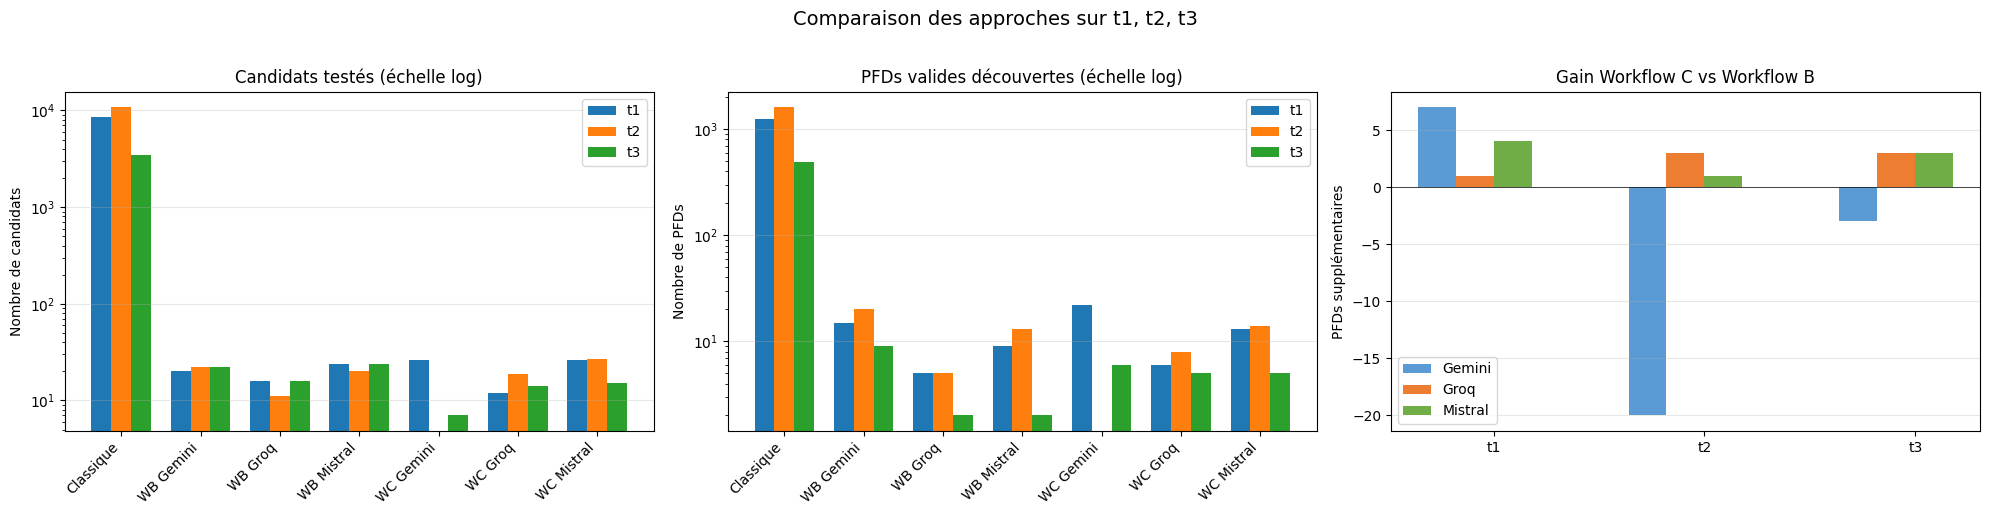

In [31]:
llm_names = list(clients.keys())
ds_names = ['t1', 't2', 't3']
cls_data = {'t1': (cls_t1, n_cls_t1), 't2': (cls_t2, n_cls_t2), 't3': (cls_t3, n_cls_t3)}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Graphique 1 : candidats testés (échelle log)
labels = ['Classique'] + [f'WB {l.capitalize()}' for l in llm_names] + \
         [f'WC {l.capitalize()}' for l in llm_names]
x = list(range(len(labels)))

ax = axes[0]
width = 0.25
for i, ds in enumerate(ds_names):
    cls_pfds, n_cls = cls_data[ds]
    data = [n_cls]
    for ln in llm_names:
        data.append(results_wb.get((ds, ln)).candidates_tested
                    if (ds, ln) in results_wb else 0)
    for ln in llm_names:
        data.append(results_wc.get((ds, ln)).candidates_tested
                    if (ds, ln) in results_wc else 0)
    ax.bar([xi + i * width for xi in x], data, width=width, label=ds)
ax.set_yscale('log')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Candidats testés (échelle log)')
ax.set_ylabel('Nombre de candidats')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Graphique 2 : PFDs valides
ax = axes[1]
for i, ds in enumerate(ds_names):
    cls_pfds, _ = cls_data[ds]
    data = [len(cls_pfds)]
    for ln in llm_names:
        data.append(len(results_wb.get((ds, ln)).valid_pfds)
                    if (ds, ln) in results_wb else 0)
    for ln in llm_names:
        data.append(len(results_wc.get((ds, ln)).valid_pfds)
                    if (ds, ln) in results_wc else 0)
    ax.bar([xi + i * width for xi in x], data, width=width, label=ds)
ax.set_yscale('log')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('PFDs valides découvertes (échelle log)')
ax.set_ylabel('Nombre de PFDs')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Graphique 3 : gain Workflow C vs Workflow B
ax = axes[2]
colors = ['#5B9BD5', '#ED7D31', '#70AD47', '#FFC000']
x2 = list(range(len(ds_names)))
bar_width = 0.18
for i, ln in enumerate(llm_names):
    gains = []
    for ds in ds_names:
        b = len(results_wb.get((ds, ln)).valid_pfds) if (ds, ln) in results_wb else 0
        c = len(results_wc.get((ds, ln)).valid_pfds) if (ds, ln) in results_wc else 0
        gains.append(c - b)
    ax.bar([xi + (i - 1.5) * bar_width for xi in x2], gains, width=bar_width,
           label=ln.capitalize(), color=colors[i % len(colors)])
ax.set_xticks(x2)
ax.set_xticklabels(ds_names)
ax.set_title('Gain Workflow C vs Workflow B')
ax.set_ylabel('PFDs supplémentaires')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison des approches sur t1, t2, t3', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Export des résultats

On exporte toutes les PFDs trouvées en CSV pour pouvoir les inclure dans le rapport.

In [32]:
def export_pfds(pfds, path, llm_name="-", approach="-"):
    """Exporte une liste de PFDs en CSV."""
    if not pfds:
        return
    rows = []
    for r in pfds:
        rows.append({
            "approach":    approach,
            "llm":         llm_name,
            "col_X":       r.get("col_X", ""),
            "pattern_X":   r.get("pattern_X", ""),
            "match_type":  r.get("match_type_X", "exact"),
            "col_Y":       r.get("col_Y", ""),
            "pattern_Y":   r.get("pattern_Y", ""),
            "confidence":  r.get("confidence", 0),
            "support":     r.get("n_matching_X", 0),
            "violations":  r.get("n_violations", 0),
        })
    pd.DataFrame(rows).to_csv(path, index=False)
    print(f"Exporté : {path}")


# Algo classique
export_pfds(cls_t1, "results_classique_t1.csv", "-", "Classique")
export_pfds(cls_t2, "results_classique_t2.csv", "-", "Classique")
export_pfds(cls_t3, "results_classique_t3.csv", "-", "Classique")

# Workflows agentiques
for (ds_name, llm_name), wb in results_wb.items():
    export_pfds(wb.valid_pfds, f"results_wb_{ds_name}_{llm_name}.csv",
                llm_name, "WB")
for (ds_name, llm_name), wc in results_wc.items():
    export_pfds(wc.valid_pfds, f"results_wc_{ds_name}_{llm_name}.csv",
                llm_name, "WC")

Exporté : results_classique_t1.csv
Exporté : results_classique_t2.csv
Exporté : results_classique_t3.csv
Exporté : results_wb_t1_gemini.csv
Exporté : results_wb_t1_groq.csv
Exporté : results_wb_t1_mistral.csv
Exporté : results_wb_t2_gemini.csv
Exporté : results_wb_t2_groq.csv
Exporté : results_wb_t2_mistral.csv
Exporté : results_wb_t3_gemini.csv
Exporté : results_wb_t3_groq.csv
Exporté : results_wb_t3_mistral.csv
Exporté : results_wc_t1_gemini.csv
Exporté : results_wc_t1_groq.csv
Exporté : results_wc_t1_mistral.csv
Exporté : results_wc_t2_groq.csv
Exporté : results_wc_t2_mistral.csv
Exporté : results_wc_t3_gemini.csv
Exporté : results_wc_t3_groq.csv
Exporté : results_wc_t3_mistral.csv


## 11. Analyse qualitative des règles

Le comptage des PFDs ne dit pas tout. Pour comparer vraiment les approches, on regarde les règles trouvées une par une et on essaie d'évaluer leur intérêt sémantique.

Pour chaque dataset, on affiche côte à côte :
- les 5 meilleures règles de l'algorithme classique
- les règles trouvées par le Workflow B avec chaque LLM
- les règles trouvées par le Workflow C avec chaque LLM

> **Ce qu'on cherche à voir** : est-ce que les workflows agentiques trouvent des règles plus pertinentes sémantiquement (par exemple `ZIP startswith 606 → CITY = Chicago`) ou des règles triviales similaires à l'algorithme classique (par exemple `ZIP startswith 6 → COUNTRY = United States`).

In [33]:
def display_pfds_table(pfds, title, max_rules=10):
    """Affiche les PFDs sous forme de DataFrame pandas pour une lecture facile."""
    if not pfds:
        print(f"\n--- {title} ---")
        print("Aucune PFD trouvée.")
        return None

    rows = []
    for r in pfds[:max_rules]:
        rows.append({
            "Règle": (f"{r.get('match_type_X', 'exact')}({r['col_X']}, "
                     f"'{r['pattern_X']}') -> {r['col_Y']}='{r['pattern_Y']}'"),
            "Confiance": f"{r['confidence']:.1%}",
            "Support": r.get("n_matching_X", 0),
            "Violations": r.get("n_violations", 0),
        })
    df_display = pd.DataFrame(rows)
    print(f"\n--- {title} ({len(pfds)} règles trouvées, top {min(max_rules, len(pfds))} affichées) ---")
    display(df_display)
    return df_display

### 11.1 — Règles découvertes sur t1 (Employés du comté de Montgomery)

In [34]:
display_pfds_table(cls_t1, "Algo classique — t1", max_rules=10)

for llm_name in clients:
    if ('t1', llm_name) in results_wb:
        display_pfds_table(
            results_wb[('t1', llm_name)].valid_pfds,
            f"Workflow B — {llm_name.capitalize()} — t1",
            max_rules=15,
        )

for llm_name in clients:
    if ('t1', llm_name) in results_wc:
        display_pfds_table(
            results_wc[('t1', llm_name)].valid_pfds,
            f"Workflow C — {llm_name.capitalize()} — t1",
            max_rules=15,
        )


--- Algo classique — t1 (1244 règles trouvées, top 10 affichées) ---


,Règle,Confiance,Support,Violations
0,"endswith(Department, 'OL') -> Department Name=...",100.0%,1835,0
1,"endswith(Department, 'POL') -> Department Name...",100.0%,1835,0
2,"exact(Department, 'POL') -> Department Name='D...",100.0%,1835,0
3,"exact(Department Name, 'Department of Police')...",100.0%,1835,0
4,"contains(Department Name, 'Police') -> Departm...",100.0%,1835,0
5,"endswith(Department, 'HHS') -> Department Name...",100.0%,1512,0
6,"exact(Department, 'HHS') -> Department Name='D...",100.0%,1512,0
7,"exact(Department Name, 'Department of Health a...",100.0%,1512,0
8,"contains(Department Name, 'Health') -> Departm...",100.0%,1512,0
9,"startswith(Department, 'F') -> Assignment Cate...",100.0%,1392,0



--- Workflow B — Gemini — t1 (15 règles trouvées, top 15 affichées) ---


,Règle,Confiance,Support,Violations
0,"exact(Department, 'POL') -> Department Name='D...",100.0%,1835,0
1,"exact(Department, 'HHS') -> Department Name='D...",100.0%,1512,0
2,"exact(Department, 'COR') -> Department Name='C...",100.0%,494,0
3,"startswith(Department Name, 'Correction') -> D...",100.0%,494,0
4,"endswith(Department Name, 'Police') -> Departm...",100.0%,1835,0
5,"contains(Position Title, 'Police') -> Departme...",100.0%,1248,0
6,"contains(Position Title, 'Correctional') -> De...",100.0%,402,0
7,"contains(Position Title, 'Sheriff') -> Departm...",100.0%,141,0
8,"contains(Position Title, 'Firefighter') -> Dep...",100.0%,867,0
9,"contains(Underfilled Job Title, 'Police Office...",100.0%,278,0



--- Workflow B — Groq — t1 (5 règles trouvées, top 5 affichées) ---


...

,Règle,Confiance,Support,Violations
0,"exact(Department, 'POL') -> Department Name='D...",100.0%,1835,0
1,"exact(Department, 'HHS') -> Department Name='D...",100.0%,1512,0
2,"exact(Department, 'COR') -> Department Name='C...",100.0%,494,0
3,"exact(Department, 'HCA') -> Department Name='D...",100.0%,75,0
4,"exact(Department, 'DGS') -> Department Name='D...",100.0%,400,0
5,"startswith(Department Name, 'Department of Pol...",100.0%,1835,0
6,"startswith(Division, 'MSB') -> Department='POL'",100.0%,287,0
7,"endswith(Department Name, 'Police') -> Departm...",100.0%,1835,0
8,"endswith(Department Name, 'Human Services') ->...",100.0%,1512,0
9,"endswith(Department Name, 'General Services') ...",100.0%,400,0



--- Workflow C — Groq — t1 (6 règles trouvées, top 6 affichées) ---


,Règle,Confiance,Support,Violations
0,"exact(Department, 'POL') -> Department Name='D...",100.0%,1835,0
1,"contains(Position Title, 'Police') -> Departme...",100.0%,1248,0
2,"startswith(Division, 'ISB') -> Department='POL'",100.0%,218,0
3,"contains(Department Name, 'Health') -> Departm...",100.0%,1512,0
4,"startswith(Division, 'MSB') -> Department='POL'",100.0%,287,0
5,"contains(Department Name, 'Rehabilitation') ->...",100.0%,494,0



--- Workflow C — Mistral — t1 (13 règles trouvées, top 13 affichées) ---


,Règle,Confiance,Support,Violations
0,"exact(Department, 'POL') -> Department Name='D...",100.0%,1835,0
1,"exact(Department, 'HHS') -> Department Name='D...",100.0%,1512,0
2,"exact(Department, 'COR') -> Department Name='C...",100.0%,494,0
3,"exact(Department, 'HCA') -> Department Name='D...",100.0%,75,0
4,"exact(Department, 'DGS') -> Department Name='D...",100.0%,400,0
5,"contains(Position Title, 'Police') -> Departme...",100.0%,1248,0
6,"contains(Underfilled Job Title, 'Police Office...",100.0%,278,0
7,"contains(Underfilled Job Title, 'Correctional ...",100.0%,90,0
8,"contains(Division, 'Major Crimes') -> Departme...",100.0%,51,0
9,"contains(Position Title, 'Social Worker') -> D...",99.5%,211,1


### 11.2 — Règles découvertes sur t2 (Employeurs Chicago)

In [35]:
display_pfds_table(cls_t2, "Algo classique — t2", max_rules=10)

for llm_name in clients:
    if ('t2', llm_name) in results_wb:
        display_pfds_table(
            results_wb[('t2', llm_name)].valid_pfds,
            f"Workflow B — {llm_name.capitalize()} — t2",
            max_rules=15,
        )

for llm_name in clients:
    if ('t2', llm_name) in results_wc:
        display_pfds_table(
            results_wc[('t2', llm_name)].valid_pfds,
            f"Workflow C — {llm_name.capitalize()} — t2",
            max_rules=15,
        )


--- Algo classique — t2 (1611 règles trouvées, top 10 affichées) ---


,Règle,Confiance,Support,Violations
0,"startswith(ZIP, '6') -> COUNTRY='United States'",100.0%,2509,0
1,"endswith(CITY, 'go') -> COUNTRY='United States'",100.0%,2145,0
2,"endswith(CITY, 'ago') -> COUNTRY='United States'",100.0%,2144,0
3,"contains(CITY, 'Chicago') -> COUNTRY='United S...",100.0%,2124,0
4,"exact(CITY, 'Chicago') -> COUNTRY='United States'",100.0%,2116,0
5,"startswith(PHONE, '3') -> COUNTRY='United States'",100.0%,1978,0
6,"startswith(EMPLOYER_ID, '4') -> COUNTRY='Unite...",100.0%,1876,0
7,"startswith(FAX, '3') -> COUNTRY='United States'",100.0%,1459,0
8,"startswith(EMPLOYER_ID, '1') -> ACTIVE='Y'",100.0%,734,0
9,"endswith(Year, '1.0') -> COUNTRY='United States'",100.0%,711,0



--- Workflow B — Gemini — t2 (20 règles trouvées, top 15 affichées) ---


,Règle,Confiance,Support,Violations
0,"exact(STATE, 'Il') -> COUNTRY='United States'",100.0%,54,0
1,"exact(STATE, 'CA') -> COUNTRY='United States'",100.0%,73,0
2,"startswith(CITY, 'New') -> STATE='NY'",100.0%,267,0
3,"endswith(NAME, 'LLP') -> COUNTRY='United States'",100.0%,337,0
4,"endswith(NAME, 'LLC') -> COUNTRY='United States'",100.0%,607,0
5,"startswith(ZIP, '60') -> COUNTRY='United States'",100.0%,2456,0
6,"exact(STATE, 'IL') -> COUNTRY='United States'",99.9%,2441,3
7,"contains(ADDRESS_1, 'LaSalle') -> CITY='Chicago'",99.4%,350,2
8,"exact(STATE, 'NY') -> COUNTRY='United States'",98.3%,303,5
9,"startswith(ZIP, '606') -> CITY='Chicago'",98.3%,2131,37



--- Workflow B — Groq — t2 (5 règles trouvées, top 5 affichées) ---


...

,Règle,Confiance,Support,Violations
0,"contains(NAME, 'LLC') -> COUNTRY='United States'",100.0%,633,0
1,"contains(NAME, 'LLP') -> COUNTRY='United States'",100.0%,344,0
2,"exact(STATE, 'CA') -> COUNTRY='United States'",100.0%,73,0
3,"exact(STATE, 'IL') -> COUNTRY='United States'",99.9%,2441,3
4,"contains(ADDRESS_1, 'LaSalle') -> CITY='Chicago'",99.4%,350,2
5,"exact(ZIP, '60603') -> CITY='Chicago'",98.9%,279,3
6,"exact(STATE, 'NY') -> COUNTRY='United States'",98.3%,303,5
7,"startswith(ZIP, '606') -> CITY='Chicago'",98.3%,2131,37
8,"startswith(ZIP, '60') -> STATE='IL'",97.7%,2456,57
9,"contains(ADDRESS_1, 'Dearborn') -> CITY='Chicago'",97.4%,114,3



--- Workflow C — Gemini — t2 ---
Aucune PFD trouvée.

--- Workflow C — Groq — t2 (8 règles trouvées, top 8 affichées) ---


,Règle,Confiance,Support,Violations
0,"exact(STATE, 'CA') -> COUNTRY='United States'",100.0%,73,0
1,"exact(CITY, 'New York') -> STATE='NY'",100.0%,267,0
2,"exact(STATE, 'IL') -> COUNTRY='United States'",99.9%,2441,3
3,"exact(STATE, 'NY') -> COUNTRY='United States'",98.3%,303,5
4,"startswith(ZIP, '606') -> CITY='Chicago'",98.3%,2131,37
5,"startswith(ZIP, '60') -> STATE='IL'",97.7%,2456,57
6,"startswith(PHONE, '312') -> CITY='Chicago'",95.1%,1903,93
7,"startswith(PHONE, '773') -> CITY='Chicago'",91.8%,220,18



--- Workflow C — Mistral — t2 (14 règles trouvées, top 14 affichées) ---


,Règle,Confiance,Support,Violations
0,"contains(NAME, 'LLC') -> COUNTRY='United States'",100.0%,633,0
1,"contains(NAME, 'LLP') -> COUNTRY='United States'",100.0%,344,0
2,"exact(STATE, 'MA') -> COUNTRY='United States'",100.0%,37,0
3,"exact(STATE, 'IL') -> COUNTRY='United States'",99.9%,2441,3
4,"exact(ACTIVE, 'Y') -> COUNTRY='United States'",99.6%,3396,12
5,"exact(ZIP, '60601') -> CITY='Chicago'",99.0%,409,4
6,"exact(ZIP, '60603') -> CITY='Chicago'",98.9%,279,3
7,"contains(ADDRESS_1, 'Clark St') -> CITY='Chicago'",98.8%,81,1
8,"exact(STATE, 'NY') -> COUNTRY='United States'",98.3%,303,5
9,"startswith(ZIP, '606') -> CITY='Chicago'",98.3%,2131,37


### 11.3 — Règles découvertes sur t3 (Licences alcool Maryland)

In [36]:
display_pfds_table(cls_t3, "Algo classique — t3", max_rules=10)

for llm_name in clients:
    if ('t3', llm_name) in results_wb:
        display_pfds_table(
            results_wb[('t3', llm_name)].valid_pfds,
            f"Workflow B — {llm_name.capitalize()} — t3",
            max_rules=15,
        )

for llm_name in clients:
    if ('t3', llm_name) in results_wc:
        display_pfds_table(
            results_wc[('t3', llm_name)].valid_pfds,
            f"Workflow C — {llm_name.capitalize()} — t3",
            max_rules=15,
        )


--- Algo classique — t3 (488 règles trouvées, top 10 affichées) ---


,Règle,Confiance,Support,Violations
0,"endswith(Zip, '.0') -> State='MD'",100.0%,1076,0
1,"startswith(Zip, '2') -> State='MD'",100.0%,1076,0
2,"endswith(Channel Type, 'se') -> State='MD'",100.0%,1075,0
3,"endswith(Channel Type, 'ise') -> State='MD'",100.0%,1075,0
4,"contains(Channel Type, 'Premise') -> State='MD'",100.0%,1075,0
5,"startswith(Channel Type, 'O') -> State='MD'",100.0%,1075,0
6,"exact(Channel Type, 'On Premise') -> State='MD'",100.0%,789,0
7,"startswith(Licensee Number, 'B') -> State='MD'",100.0%,625,0
8,"startswith(Location, '1') -> State='MD'",100.0%,401,0
9,"startswith(Street, '1') -> State='MD'",100.0%,401,0



--- Workflow B — Gemini — t3 (9 règles trouvées, top 9 affichées) ---


,Règle,Confiance,Support,Violations
0,"startswith(Zip, '20814') -> City='BETHESDA'",100.0%,137,0
1,"endswith(Account Name, 'LLC') -> State='MD'",100.0%,360,0
2,"endswith(Street, 'BOULEVARD') -> State='MD'",100.0%,25,0
3,"exact(City, 'BETHESDA') -> State='MD'",100.0%,170,0
4,"exact(City, 'GAITHERSBURG') -> State='MD'",100.0%,171,0
5,"startswith(Zip, '20878') -> City='GAITHERSBURG'",98.8%,83,1
6,"contains(Licensee Name, 'BAR') -> Channel Type...",95.5%,44,2
7,"startswith(Licensee Number, 'BBW') -> Channel ...",95.1%,614,30
8,"startswith(Zip, '20852') -> City='ROCKVILLE'",93.7%,95,6



--- Workflow B — Groq — t3 (2 règles trouvées, top 2 affichées) ---


...

,Règle,Confiance,Support,Violations
0,"exact(City, 'ROCKVILLE') -> State='MD'",100.0%,206,0
1,"exact(City, 'SILVER SPRING') -> State='MD'",100.0%,269,0
2,"startswith(Zip, '20878') -> City='GAITHERSBURG'",98.8%,83,1
3,"contains(Licensee Name, 'BAR') -> Channel Type...",95.5%,44,2
4,"startswith(Licensee Number, 'BBW') -> Channel ...",95.1%,614,30
5,"startswith(Zip, '20852') -> City='ROCKVILLE'",93.7%,95,6



--- Workflow C — Groq — t3 (5 règles trouvées, top 5 affichées) ---


,Règle,Confiance,Support,Violations
0,"exact(City, 'ROCKVILLE') -> State='MD'",100.0%,206,0
1,"contains(Location, 'GAITHERSBURG') -> City='GA...",100.0%,171,0
2,"contains(Location, 'ROCKVILLE') -> City='ROCKV...",100.0%,206,0
3,"startswith(Zip, '208') -> State='MD'",100.0%,770,0
4,"startswith(Licensee Number, 'BBWLHR') -> Chann...",99.8%,524,1



--- Workflow C — Mistral — t3 (5 règles trouvées, top 5 affichées) ---


,Règle,Confiance,Support,Violations
0,"contains(Account Name, 'INC') -> State='MD'",100.0%,486,0
1,"startswith(Licensee Number, 'BBWLHR') -> State...",100.0%,524,0
2,"contains(Account Name, 'LLC') -> State='MD'",100.0%,389,0
3,"contains(Licensee Name, 'BAR') -> Channel Type...",95.5%,44,2
4,"endswith(Street, 'BOULEVARD') -> Channel Type=...",92.0%,25,2


### 11.4 — Recherche d'une règle phare du cours

La PFD canonique du cours est `(ZIP, startswith="606") → (CITY, "Chicago")` sur t2. Vérifions quelles approches l'ont trouvée :

In [37]:
def cherche_regle(pfds, col_X, pattern_X, col_Y, pattern_Y_contains=None):
    """Cherche une règle spécifique dans une liste de PFDs."""
    for r in pfds:
        if (r["col_X"] == col_X
            and str(r["pattern_X"]) == str(pattern_X)
            and r["col_Y"] == col_Y):
            if pattern_Y_contains is None or pattern_Y_contains.lower() in str(r["pattern_Y"]).lower():
                return r
    return None


def cherche_regle_proche(pfds, col_X, pattern_prefix, col_Y):
    """Cherche une règle où pattern_X commence par pattern_prefix."""
    for r in pfds:
        if (r["col_X"] == col_X
            and str(r["pattern_X"]).startswith(str(pattern_prefix))
            and r["col_Y"] == col_Y):
            return r
    return None


print("Recherche de la PFD du cours : ZIP startswith '606' -> CITY = 'Chicago'")
print("=" * 70)

# Algo classique
r = cherche_regle_proche(cls_t2, "ZIP", "606", "CITY")
if r:
    print(f"Algo classique : TROUVÉE — ZIP startswith '{r['pattern_X']}' -> "
          f"CITY='{r['pattern_Y']}' (conf={r['confidence']:.1%}, support={r['n_matching_X']})")
else:
    print("Algo classique : non trouvée dans le top des règles généralisées")

# Workflows agentiques
for approach, results in [("Workflow B", results_wb), ("Workflow C", results_wc)]:
    for llm_name in clients:
        if ('t2', llm_name) not in results:
            continue
        pfds = results[('t2', llm_name)].valid_pfds
        r = cherche_regle_proche(pfds, "ZIP", "606", "CITY")
        if r:
            print(f"{approach} {llm_name.capitalize():<8} : TROUVÉE — "
                  f"ZIP startswith '{r['pattern_X']}' -> CITY='{r['pattern_Y']}' "
                  f"(conf={r['confidence']:.1%}, support={r['n_matching_X']})")
        else:
            print(f"{approach} {llm_name.capitalize():<8} : NON TROUVÉE")

Recherche de la PFD du cours : ZIP startswith '606' -> CITY = 'Chicago'
Algo classique : TROUVÉE — ZIP startswith '60604' -> CITY='Chicago' (conf=100.0%, support=72)
Workflow B Gemini   : TROUVÉE — ZIP startswith '606' -> CITY='Chicago' (conf=98.3%, support=2131)
Workflow B Groq     : TROUVÉE — ZIP startswith '60603' -> CITY='Chicago' (conf=98.9%, support=279)
Workflow B Mistral  : TROUVÉE — ZIP startswith '60603' -> CITY='Chicago' (conf=98.9%, support=279)
Workflow C Gemini   : NON TROUVÉE
Workflow C Groq     : TROUVÉE — ZIP startswith '606' -> CITY='Chicago' (conf=98.3%, support=2131)
Workflow C Mistral  : TROUVÉE — ZIP startswith '60601' -> CITY='Chicago' (conf=99.0%, support=409)


### 11.5 — Synthèse de la pertinence sémantique

Cette dernière analyse compte combien de règles, parmi celles trouvées par chaque approche, sont sémantiquement intéressantes versus triviales. On considère qu'une règle est triviale si :

- elle dit quelque chose comme `X startswith "1 caractère" → COUNTRY = "valeur dominante"`
- ou si elle pointe vers une valeur qui domine tout le dataset (> 95 % de présence)

In [38]:
def is_trivial(rule, df):
    """
    Heuristique pour déterminer si une règle est triviale.
    Une règle est triviale si :
      - Son pattern_X est trop court sur startswith (<= 2 caractères)
      - Sa valeur pattern_Y domine la colonne cible à plus de 95 %
    """
    if rule.get("match_type_X") == "startswith" and len(str(rule["pattern_X"])) <= 2:
        return True
    col_Y = rule["col_Y"]
    if col_Y in df.columns:
        n_total = df[col_Y].notna().sum()
        if n_total > 0:
            n_target = (df[col_Y] == rule["pattern_Y"]).sum()
            if n_target / n_total >= 0.95:
                return True
    return False


def analyse_pertinence(pfds, df, label, n_candidates=None):
    """Compte les règles triviales vs pertinentes et calcule le taux de validation."""
    if not pfds:
        return {"label": label, "candidats": n_candidates or 0,
                "valides": 0, "taux_valid": "0%",
                "triviales": 0, "pertinentes": 0, "pct_pertinentes": 0}

    triviales = sum(1 for r in pfds if is_trivial(r, df))
    pertinentes = len(pfds) - triviales
    pct = (pertinentes / len(pfds) * 100) if pfds else 0
    taux_valid = (len(pfds) / n_candidates * 100) if n_candidates else None

    return {
        "label": label,
        "candidats": n_candidates or 0,
        "valides": len(pfds),
        "taux_valid": f"{taux_valid:.0f}%" if taux_valid is not None else "n/a",
        "triviales": triviales,
        "pertinentes": pertinentes,
        "pct_pertinentes": round(pct, 1),
    }


# Tableau d'analyse incluant le taux de validation
rows_analyse = []
for ds_name, df_ds, cls_pfds, n_cls in [
    ("t1", t1, cls_t1, n_cls_t1),
    ("t2", t2, cls_t2, n_cls_t2),
    ("t3", t3, cls_t3, n_cls_t3),
]:
    rows_analyse.append({"Dataset": ds_name,
                         **analyse_pertinence(cls_pfds, df_ds, "Classique", n_cls)})
    for llm_name in clients:
        if (ds_name, llm_name) in results_wb:
            wb = results_wb[(ds_name, llm_name)]
            r = analyse_pertinence(wb.valid_pfds, df_ds,
                                   f"WB {llm_name.capitalize()}",
                                   n_candidates=wb.candidates_tested)
            rows_analyse.append({"Dataset": ds_name, **r})
        if (ds_name, llm_name) in results_wc:
            wc = results_wc[(ds_name, llm_name)]
            r = analyse_pertinence(wc.valid_pfds, df_ds,
                                   f"WC {llm_name.capitalize()}",
                                   n_candidates=wc.candidates_tested)
            rows_analyse.append({"Dataset": ds_name, **r})

df_analyse = pd.DataFrame(rows_analyse)
print("Analyse complète : candidats, validation, pertinence sémantique")
print("=" * 80)
display(df_analyse)

Analyse complète : candidats, validation, pertinence sémantique


,Dataset,label,candidats,valides,taux_valid,triviales,pertinentes,pct_pertinentes
0,t1,Classique,8615,1244,14%,161,1083,87.1
1,t1,WB Gemini,20,15,75%,0,15,100.0
2,t1,WC Gemini,26,22,85%,0,22,100.0
3,t1,WB Groq,16,5,31%,0,5,100.0
4,t1,WC Groq,12,6,50%,0,6,100.0
5,t1,WB Mistral,24,9,38%,1,8,88.9
6,t1,WC Mistral,26,13,50%,1,12,92.3
7,t2,Classique,10786,1611,15%,1176,435,27.0
8,t2,WB Gemini,22,20,91%,8,12,60.0
9,t2,WC Gemini,0,0,0%,0,0,0.0


## 12. Bilan

On résume ici ce qu'on a observé sur nos trois datasets.

L'algorithme classique trouve plusieurs centaines de règles par dataset, mais une grande partie est triviale (préfixes très courts vers des valeurs dominantes). Le coût computationnel reste limité parce qu'on travaille sur des datasets de quelques milliers de lignes.

Le Workflow B réduit massivement l'espace exploré : on passe de plusieurs milliers de candidats à une vingtaine. Les règles trouvées sont plus ciblées sémantiquement, avec un seul appel API par dataset.

Le Workflow C apporte un gain mesurable par rapport au Workflow B. Le tour 2 corrige les candidats presque valides, et le tour 3 découvre des règles que le LLM n'avait pas pensé à proposer au premier coup. En contrepartie, on multiplie les appels API par trois.

> **Remarque** — L'intérêt du Workflow C est que le LLM apprend de ses propres erreurs. C'est ce qui distingue vraiment l'approche agentique d'un simple appel ponctuel.

La comparaison entre les trois LLMs (Gemini, Groq, Mistral) montre qu'on ne dépend pas d'un seul fournisseur, et permet d'identifier celui qui produit les règles les plus pertinentes selon le type de dataset.